# 012 — Sampling uncertainty in asset-pricing Sharpe comparisons

## Purpose and questions
We extend Codes 07–11 by quantifying return-sample uncertainty without retraining any model.
**Q1:** How uncertain is each model's test Sharpe? **Q2:** Which paired Sharpe differences exclude zero?
**Q3:** Do conclusions change with block length? **Q4:** Does the blend improve on LSTM beyond sampling noise?

## Process
1. Validate the same 300 test months (1992–2016), five saved portfolios, and the Equal-weight LSTM–Transformer combination.
2. Resample contiguous circular blocks, applying exactly the same month indices to every portfolio.
3. Compute 10,000 replicates at 6-, 12-, and 24-month block lengths. Twelve months is the primary
   illustrative choice, fixed before this analysis; it is not a data-selected optimal block length.
4. Report monthly and conventionally annualized Sharpe, pointwise basic and percentile intervals,
   and approximate simultaneous intervals for all ten paired differences.
5. Save tables, figures, reproducibility metadata, and answers. No model is trained or selected here.

## Method and limits
Basic intervals use observed estimate minus the reversed bootstrap-error quantiles. Percentile intervals
use the replicate quantiles. Simultaneous intervals use the 95th percentile of the maximum absolute
centered error across all ten differences, without studentization. These are approximate bootstrap
intervals, not exact finite-sample guarantees. Report both interval methods and block sensitivity.
Circular blocks wrap the sample boundary; local dependence is retained inside each block, not across
randomly joined blocks. Stationarity/weak-dependence assumptions may fail over a changing 25-year market.
Annualized Sharpe equals monthly Sharpe times sqrt(12), following our existing convention; it is not
an autocorrelation-adjusted long-horizon Sharpe. The portfolios are fixed: training, seed-selection,
generator/data uncertainty, costs, and repeated examination of the test sample are not corrected here.
A bootstrap interval containing zero does not establish equivalence. Bootstrap sign frequencies are
not posterior probabilities or automatically valid hypothesis-test p-values.

References: [CMU time-series bootstrap notes](https://www.stat.cmu.edu/~cshalizi/dst/20/lectures/16/lecture-16.html)
and [arch circular-block documentation](https://arch.readthedocs.io/en/stable/bootstrap/timeseries-bootstraps.html).

**Rolling extension:** Part 10 analyzes all complete 36- and 60-month windows with 2,000 paired bootstrap draws each, six-month primary blocks, and December-endpoint sensitivity. Seven named figures are saved in PNG and PDF.

**Viewing the results:** Outputs are expanded, and table columns wrap to fit the page. Scroll down the notebook normally to read all results; there are no intentional scrolling boxes inside result cells. Run the first display-settings cell if your Jupyter session needs to reapply the layout.


In [0]:
# Display complete results without internal output scrolling.
from IPython.display import display, HTML
import pandas as pd
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)
display(HTML('<style>\n/* Code 012: expand saved and newly executed results in classic Notebook and JupyterLab. */\n.output_scroll, .output_subarea, .output_area, .jp-OutputArea-output,\n.jp-OutputArea-child, .jp-OutputArea, .jp-RenderedHTMLCommon,\n.jp-mod-outputsScrolled .jp-OutputArea, .jp-mod-outputsScrolled .jp-Cell-outputArea {\n    max-height: none !important; height: auto !important; overflow: visible !important;\n}\n.output_scroll { box-shadow: none !important; }\n.jp-OutputArea-output img, .output_png img {\n    max-width: 100% !important; height: auto !important;\n}\ntable.dataframe {\n    width: 100% !important; max-width: 100% !important;\n    table-layout: fixed !important; font-size: 12px !important;\n}\ntable.dataframe th, table.dataframe td {\n    white-space: normal !important; overflow-wrap: anywhere !important;\n    padding: 7px 4px !important; vertical-align: top !important;\n}\n</style>'))


Complete output display enabled.

## Part 1 — Identify and validate the comparison sample
**Explanation:** Every portfolio must refer to the same months. Otherwise a difference in Sharpe could
reflect different evaluation periods. The authors' saved factor series is used here, rather than treating
the rounded published Sharpe as a random sample. The new architectures use a reduced schedule;
historical Code 07 and the authors' model are contextual comparisons, not matched training experiments.
**Questions:** Are there 300 aligned months? Does the blend equal the average of the two returns?
**Answer:** The checks below stop execution if either condition fails. Passing them establishes input
consistency, not equivalence of model training or a fresh independent holdout.

In [1]:
from pathlib import Path
from itertools import combinations
import hashlib
import json
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path.cwd()
if not (ROOT / 'results/consolidated_comparison').exists():
    ROOT = ROOT.parent
assert (ROOT / 'results/consolidated_comparison').exists(), 'Run from the repository root or notebooks folder.'
OUT = ROOT / 'results/bootstrap_uncertainty'
for sub in ['tables', 'figures']:
    (OUT / sub).mkdir(parents=True, exist_ok=True)
CONFIG = dict(replicates=10000, block_lengths=[6, 12, 24], primary_block=12,
              random_seed=20261006, confidence=.95, sharpe_ddof=0, batch_size=128)
SOURCE = ROOT / 'results/consolidated_comparison/tables/official_extended_test_returns.csv'
SOURCE_NAMES = ['Official GAN', 'GAN–LSTM original', 'GAN–LSTM reduced schedule',
                'GAN–Transformer reduced schedule', '50/50 blend']
NAMES = ['Original-paper GAN', 'Our replicated GAN', 'Extension LSTM', 'Transformer', 'Equal-weight LSTM–Transformer combination']
COLORS = ['#94A3B8', '#003262', '#2563EB', '#B7790B', '#16816B']
returns = pd.read_csv(SOURCE, parse_dates=['date']).set_index('date')
assert list(returns.columns) == SOURCE_NAMES
assert returns.index.equals(pd.date_range('1992-01-01', '2016-12-01', freq='MS'))
X = returns.to_numpy(dtype=np.float64)
assert X.shape == (300, 5) and np.isfinite(X).all() and (X > -1).all()
np.testing.assert_allclose(X[:, 4], .5 * (X[:, 2] + X[:, 3]), atol=1e-14, rtol=1e-12)
returns.columns = NAMES

def sharpe(a, axis=0):
    sigma = np.std(a, axis=axis, ddof=0)
    if np.any(sigma <= 1e-12):
        raise ValueError('Degenerate return variance: do not silently discard replicates.')
    return np.mean(a, axis=axis) / sigma

point = sharpe(X)
np.testing.assert_allclose(point, [.749920, .611887568, .459293278, .304476897, .463102912], atol=1e-6)
display(pd.DataFrame({'model': NAMES, 'months': 300, 'monthly_sharpe': point,
                      'annualized_sharpe': point * np.sqrt(12)}))

,model,months,monthly_sharpe,annualized_sharpe
0,Original-paper GAN,300,0.749920,2.597799
1,Our replicated GAN,300,0.611888,2.119641
2,Extension LSTM,300,0.459293,1.591039
3,Transformer,300,0.304477,1.054739
4,Equal-weight LSTM–Transformer combination,300,0.463103,1.604236


### Part 1 interpretation — What is being compared?

**The statistic.** Monthly Sharpe is the sample mean monthly excess return divided by its monthly standard deviation. It measures average excess return relative to variability; it is not a percentage return. For example, LSTM Sharpe 0.459 does not mean a 45.9% return. We use `ddof=0` to match the preceding comparisons.

**Read the first table.** Each row is a fixed saved portfolio evaluated on exactly the same 300 months. Original-paper GAN is the authors' actual monthly series; Code 07 is our historical replication; Extension LSTM and Transformer are the matched reduced-budget ensembles. The blend is the average of the two new portfolio returns. It is not the average of their Sharpe ratios.

**Why the checks matter.** Calendar equality prevents comparing different market periods. The blend assertion checks its construction. Reproducing the previously reported Sharpes checks that this notebook uses the intended data. These checks cannot establish that all models had identical training procedures.

**Answer:** The observed ranking is Original-paper GAN, Our replicated GAN, blend, Extension LSTM, Transformer. This is a sample ranking. The later intervals ask how uncertain its pairwise differences are.

## Paired circular block bootstrap and integrity checks
Each replicate samples ceil(300 / block_length) block starts uniformly with replacement, expands
them into consecutive month indices modulo 300, and trims the last block to 300 observations.
Every portfolio receives those same indices. Pairing preserves contemporaneous co-movement.
Sensitivity runs have deterministic separate random streams. Random seeds here control resampling,
not model training. The small checks below verify block construction, reproducibility, and pairing.

In [2]:
def block_indices(rng, n, length, count):
    starts = rng.integers(0, n, size=(count, int(np.ceil(n / length))))
    return ((starts[:, :, None] + np.arange(length)) % n).reshape(count, -1)[:, :n]

def bootstrap_sharpes(x, length, replicates, seed, batch_size=128):
    rng = np.random.default_rng(seed)
    result = np.empty((replicates, x.shape[1]))
    for start in range(0, replicates, batch_size):
        stop = min(start + batch_size, replicates)
        idx = block_indices(rng, len(x), length, stop - start)
        result[start:stop] = sharpe(x[idx], axis=1)
    assert np.isfinite(result).all()
    return result

idx = block_indices(np.random.default_rng(7), 300, 12, 4)
assert idx.shape == (4, 300) and idx.min() >= 0 and idx.max() < 300
assert np.all(np.diff(idx.reshape(4, 25, 12), axis=2) % 300 == 1)
np.testing.assert_array_equal(idx, block_indices(np.random.default_rng(7), 300, 12, 4))
probe = bootstrap_sharpes(np.column_stack([X[:, 2], X[:, 2], 2 * X[:, 2]]), 12, 32, 7)
np.testing.assert_allclose(probe[:, 0], probe[:, 1], atol=0)
np.testing.assert_allclose(probe[:, 0], probe[:, 2], atol=1e-14)
assert np.all(probe[:, 0] - probe[:, 1] == 0)
print('Input calendar, blend, baseline Sharpe, contiguous blocks, deterministic indices, and pairing checks passed.')
display(Markdown('**Part 2 answer:** Shared contiguous block indices preserve pairing across models and local time dependence inside blocks. Identical return columns produce exactly zero paired differences. This does not preserve every long-run dependency or correct structural changes.'))

Input calendar, blend, baseline Sharpe, contiguous blocks, deterministic indices, and pairing checks passed.


**Part 2 answer:** Shared contiguous block indices preserve pairing across models and local time dependence inside blocks. Identical return columns produce exactly zero paired differences. This does not preserve every long-run dependency or correct structural changes.

### Part 2 interpretation — Why resample shared blocks?

**One replicate.** With 12-month blocks, we draw 25 starting months, take 12 consecutive observations from each, and concatenate them into a 300-month synthetic sample. A block beginning near December 2016 wraps to January 1992. This wrap is a bootstrap convention, not an economically observed transition.

**Why blocks?** Monthly returns can exhibit dependence over time. Independent-month sampling discards that dependence. Blocks retain it locally, although random block boundaries break longer relationships. Six, twelve, and twenty-four months test sensitivity to this choice; none is established here as optimal.

**Why pairing?** Both portfolios must experience the same sampled market months. Otherwise a comparison introduces artificial uncertainty from different market histories. Pairing preserves contemporaneous return relationships. The identical-column test confirms that identical strategies have exactly zero differences in every replicate.

**What 10,000 means.** These are resampling experiments, not new historical observations, model fits, or independent trading strategies. More replicates reduce simulation noise but cannot create more economic information than the original sample.

**Answer:** The bootstrap approximates sampling variability conditional on the observed return history and the fixed models. It does not capture the full model-development process.

## Part 3 — Estimate confidence intervals and paired differences
**Explanation:** A difference is computed inside each shared bootstrap sample, preserving dependence
between portfolios. Comparing overlap of two separate model intervals is not a substitute for this.
**Questions:** How wide are model intervals? Does a difference interval exclude zero? Does that finding
survive adjustment for the ten comparisons? **Answer:** The following tables report all five models and
ten pairs. A positive A-minus-B estimate favors A, but an interval crossing zero leaves its sign unresolved.
The pointwise basic, percentile, and simultaneous procedures differ, so compare their conclusions.

In [3]:
PAIRS = list(combinations(range(len(NAMES)), 2))
alpha = 1 - CONFIG['confidence']
model_rows, pair_rows, draws = [], [], {}
for length in CONFIG['block_lengths']:
    bs = bootstrap_sharpes(X, length, CONFIG['replicates'],
                          np.random.SeedSequence([CONFIG['random_seed'], length]), CONFIG['batch_size'])
    draws[length] = bs
    lo, hi = np.quantile(bs, [alpha / 2, 1 - alpha / 2], axis=0)
    for j, model in enumerate(NAMES):
        model_rows.append(dict(block_months=length, model=model, monthly_sharpe=point[j],
            basic_lower=2 * point[j] - hi[j], basic_upper=2 * point[j] - lo[j],
            percentile_lower=lo[j], percentile_upper=hi[j], bootstrap_se=bs[:, j].std(ddof=1)))
    delta = np.array([point[i] - point[j] for i, j in PAIRS])
    boot_delta = np.column_stack([bs[:, i] - bs[:, j] for i, j in PAIRS])
    critical = np.quantile(np.max(np.abs(boot_delta - delta), axis=1), CONFIG['confidence'])
    qlo, qhi = np.quantile(boot_delta, [alpha / 2, 1 - alpha / 2], axis=0)
    for k, (i, j) in enumerate(PAIRS):
        lower, upper = 2 * delta[k] - qhi[k], 2 * delta[k] - qlo[k]
        sim_lo, sim_hi = delta[k] - critical, delta[k] + critical
        pair_rows.append(dict(block_months=length, model_a=NAMES[i], model_b=NAMES[j],
            difference_a_minus_b=delta[k], basic_lower=lower, basic_upper=upper,
            percentile_lower=qlo[k], percentile_upper=qhi[k],
            simultaneous_lower=sim_lo, simultaneous_upper=sim_hi,
            pointwise_excludes_zero=bool(lower > 0 or upper < 0),
            simultaneous_excludes_zero=bool(sim_lo > 0 or sim_hi < 0)))

model_ci = pd.DataFrame(model_rows)
pair_ci = pd.DataFrame(pair_rows)
for frame, estimate in [(model_ci, 'monthly_sharpe'), (pair_ci, 'difference_a_minus_b')]:
    for col in [estimate, 'basic_lower', 'basic_upper', 'percentile_lower', 'percentile_upper']:
        frame['annualized_' + col] = frame[col] * np.sqrt(12)
for col in ['simultaneous_lower', 'simultaneous_upper']:
    pair_ci['annualized_' + col] = pair_ci[col] * np.sqrt(12)
model_ci.to_csv(OUT / 'tables/model_sharpe_confidence_intervals.csv', index=False)
pair_ci.to_csv(OUT / 'tables/paired_sharpe_difference_intervals.csv', index=False)
np.savez_compressed(OUT / 'bootstrap_sharpe_draws.npz', **{f'block_{k}': v for k, v in draws.items()})
primary_models = model_ci[model_ci.block_months == CONFIG['primary_block']]
primary_pairs = pair_ci[pair_ci.block_months == CONFIG['primary_block']]
display(Markdown('### Primary 12-month blocks: monthly Sharpe and pointwise 95% basic intervals'))
display(primary_models[['model', 'monthly_sharpe', 'basic_lower', 'basic_upper', 'percentile_lower', 'percentile_upper']])
display(Markdown('### Paired differences: A minus B, monthly units'))
display(primary_pairs[['model_a', 'model_b', 'difference_a_minus_b', 'basic_lower', 'basic_upper',
                       'simultaneous_lower', 'simultaneous_upper', 'simultaneous_excludes_zero']])

### Primary 12-month blocks: monthly Sharpe and pointwise 95% basic intervals

,model,monthly_sharpe,basic_lower,basic_upper,percentile_lower,percentile_upper
5,Original-paper GAN,0.749920,0.442040,0.972515,0.527325,1.057800
6,Our replicated GAN,0.611888,0.379625,0.783478,0.440297,0.844150
7,Extension LSTM,0.459293,0.243634,0.625765,0.292821,0.674953
8,Transformer,0.304477,0.145547,0.439330,0.169624,0.463407
9,Equal-weight LSTM–Transformer combination,0.463103,0.265025,0.612491,0.313715,0.661180


### Paired differences: A minus B, monthly units

,model_a,model_b,difference_a_minus_b,basic_lower,basic_upper,simultaneous_lower,simultaneous_upper,simultaneous_excludes_zero
10,Original-paper GAN,Our replicated GAN,0.138033,-0.036797,0.255664,-0.148443,0.424508,False
11,Original-paper GAN,Extension LSTM,0.290627,-0.011909,0.536113,0.004152,0.577102,True
12,Original-paper GAN,Transformer,0.445443,0.212575,0.615292,0.158968,0.731918,True
13,Original-paper GAN,Equal-weight LSTM–Transformer combination,0.286817,0.042862,0.475137,0.000342,0.573292,True
14,Our replicated GAN,Extension LSTM,0.152594,-0.017560,0.340309,-0.133881,0.439069,False
15,Our replicated GAN,Transformer,0.307411,0.125750,0.466905,0.020936,0.593886,True
16,Our replicated GAN,Equal-weight LSTM–Transformer combination,0.148785,0.003375,0.300668,-0.137691,0.435260,False
17,Extension LSTM,Transformer,0.154816,-0.048955,0.364925,-0.131659,0.441292,False
18,Extension LSTM,Equal-weight LSTM–Transformer combination,-0.003810,-0.131614,0.118783,-0.290285,0.282666,False
19,Transformer,Equal-weight LSTM–Transformer combination,-0.158626,-0.264556,-0.057061,-0.445101,0.127849,False


### Part 3 interpretation — How to read confidence intervals

**Individual intervals.** For Extension LSTM, the monthly Sharpe estimate is 0.459 and the primary basic interval is [0.244, 0.626]. It describes uncertainty in its Sharpe under this resampling procedure. It is not a predicted range of next month's returns. The 95% label refers to the approximate repeated-sampling coverage of a procedure under its assumptions, not a 95% posterior probability about a parameter.

**Difference intervals.** Always read A minus B. LSTM minus Transformer is 0.155, with basic interval [−0.049, 0.365]. The interval includes negative values, zero, and positive values: the observed advantage is not resolved at this interval level. Do not infer the difference by inspecting whether two individual model intervals overlap.

**Pointwise versus simultaneous.** A pointwise interval addresses one comparison. Ten pointwise intervals do not collectively have a guaranteed 95% coverage rate. Our approximate simultaneous procedure calibrates the maximum absolute centered error across all ten differences. It addresses that displayed family within one block-length analysis, not all prior research decisions.

**Answer:** A higher observed Sharpe alone is insufficient to establish a clear difference. Crossing zero means unresolved direction; it does not mean the strategies are equal. A zero-excluding interval remains conditional evidence subject to the bootstrap and experimental assumptions.

## Part 4 — Figures and block-length sensitivity
**Questions:** Does the apparent ranking survive uncertainty? Does changing block length alter the answer?
**Answer:** Read intervals against the zero reference line, then compare 6-, 12-, and 24-month results.
Longer blocks do not necessarily produce wider intervals in every sample; dependence and the statistic matter.
Dots mark observed Sharpe or differences. Horizontal segments show intervals.
Simultaneous intervals address the family of ten displayed pairwise comparisons within one block-length
analysis; they do not adjust for all earlier research choices or repeated tests across block lengths.

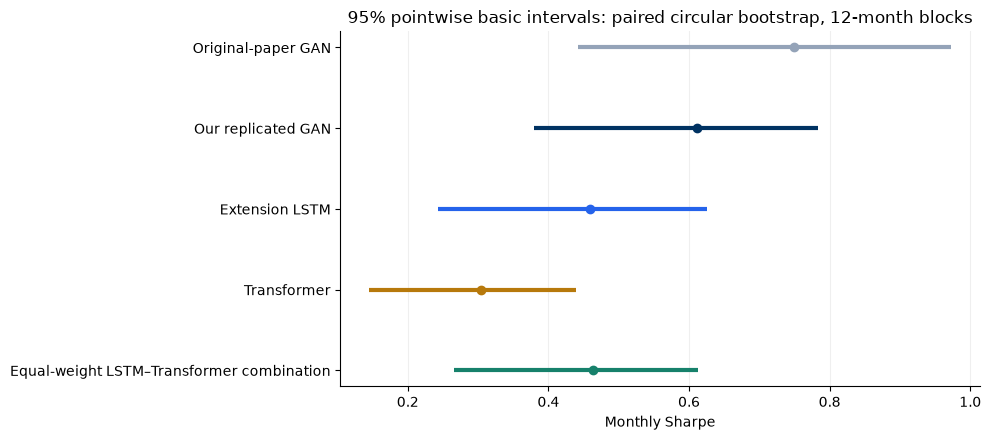

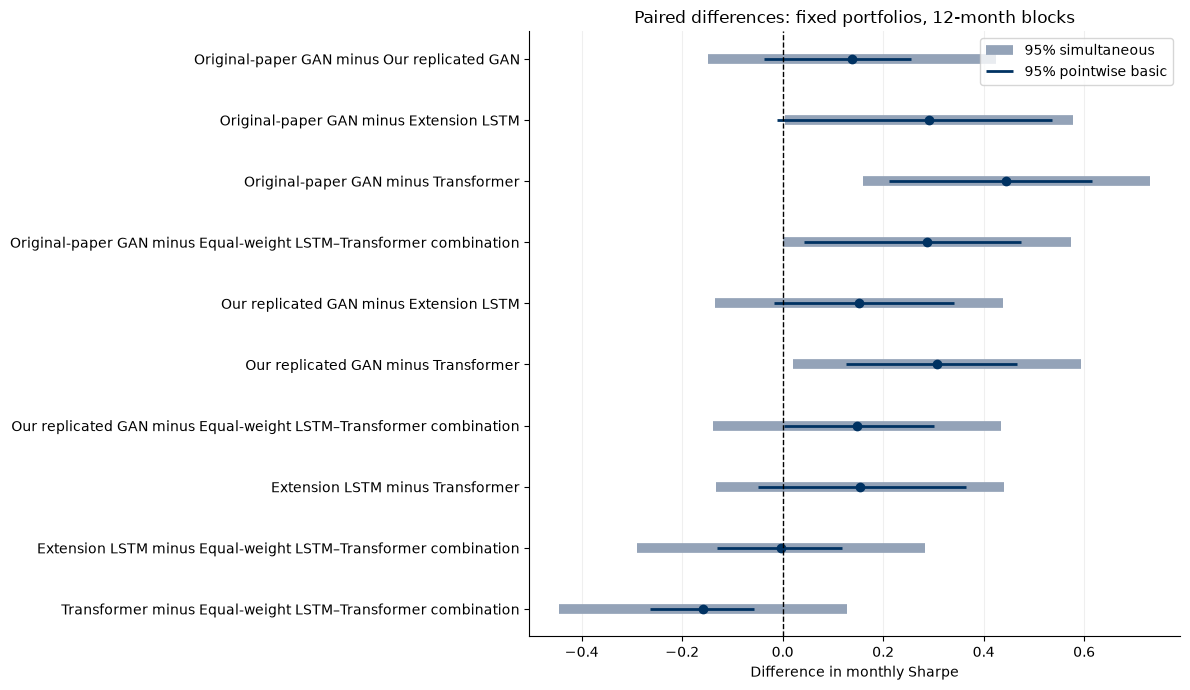

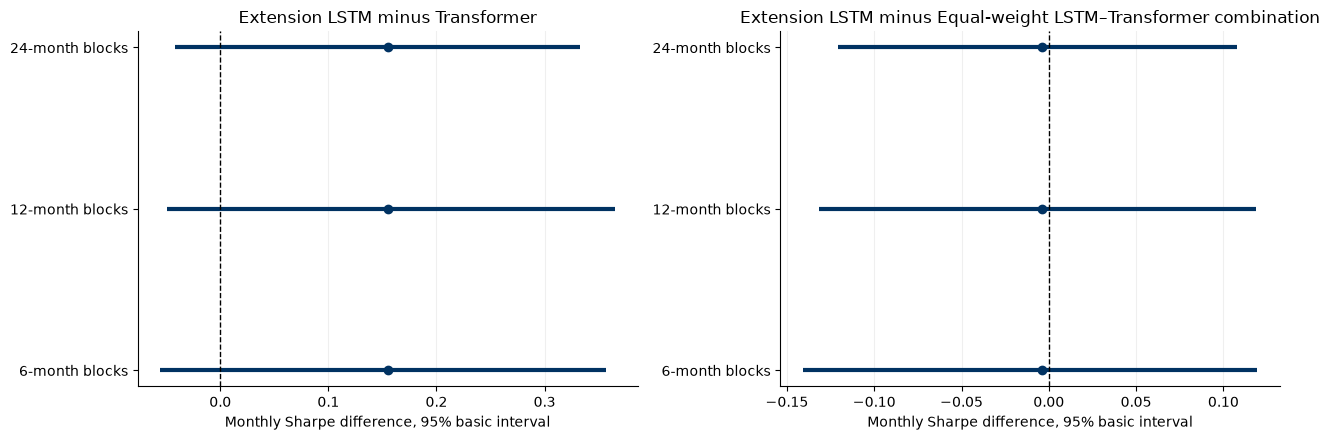

In [4]:
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False})
fig, ax = plt.subplots(figsize=(10, 4.5))
for j, row in enumerate(primary_models.itertuples()):
    ax.hlines(j, row.basic_lower, row.basic_upper, color=COLORS[j], lw=3)
    ax.plot(row.monthly_sharpe, j, 'o', color=COLORS[j])
ax.set_yticks(range(5), NAMES); ax.invert_yaxis(); ax.set_xlabel('Monthly Sharpe')
ax.set_title('95% pointwise basic intervals: paired circular bootstrap, 12-month blocks')
ax.grid(axis='x', alpha=.2); fig.tight_layout()
fig.savefig(OUT / 'figures/model_sharpe_intervals.png', dpi=170); fig.savefig(OUT / 'figures/model_sharpe_intervals.pdf', bbox_inches='tight'); plt.show()
fig, ax = plt.subplots(figsize=(12, 7))
for j, row in enumerate(primary_pairs.itertuples()):
    ax.hlines(j, row.simultaneous_lower, row.simultaneous_upper, color='#94A3B8', lw=7, label='95% simultaneous' if j == 0 else None)
    ax.hlines(j, row.basic_lower, row.basic_upper, color='#003262', lw=2, label='95% pointwise basic' if j == 0 else None)
    ax.plot(row.difference_a_minus_b, j, 'o', color='#003262')
ax.set_yticks(range(10), [f'{NAMES[i]} minus {NAMES[j]}' for i, j in PAIRS]); ax.invert_yaxis()
ax.axvline(0, color='black', ls='--', lw=1); ax.set_xlabel('Difference in monthly Sharpe')
ax.set_title('Paired differences: fixed portfolios, 12-month blocks'); ax.legend(); ax.grid(axis='x', alpha=.2)
fig.tight_layout(); fig.savefig(OUT / 'figures/paired_difference_intervals.png', dpi=170); fig.savefig(OUT / 'figures/paired_difference_intervals.pdf', bbox_inches='tight'); plt.show()
fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, (a, b) in zip(axs, [('Extension LSTM', 'Transformer'), ('Extension LSTM', 'Equal-weight LSTM–Transformer combination')]):
    q = pair_ci[(pair_ci.model_a == a) & (pair_ci.model_b == b)]
    for j, r in enumerate(q.itertuples()):
        ax.hlines(j, r.basic_lower, r.basic_upper, color='#003262', lw=3)
        ax.plot(r.difference_a_minus_b, j, 'o', color='#003262')
    ax.set_yticks(range(3), [f'{n}-month blocks' for n in q.block_months])
    ax.axvline(0, color='black', ls='--', lw=1); ax.set_title(f'{a} minus {b}')
    ax.set_xlabel('Monthly Sharpe difference, 95% basic interval'); ax.grid(axis='x', alpha=.2)
fig.tight_layout(); fig.savefig(OUT / 'figures/block_length_sensitivity.png', dpi=170); fig.savefig(OUT / 'figures/block_length_sensitivity.pdf', bbox_inches='tight'); plt.show()

### Part 4 interpretation — Reading the figures

**Model-interval figure.** Each dot is the observed monthly Sharpe. The horizontal line is the pointwise basic interval. A narrower line indicates greater estimated precision for that statistic, not necessarily a better model.

**Difference figure.** The vertical dashed line marks zero. A segment wholly to the right favors A; wholly to the left favors B. A crossing segment leaves the sign unresolved. The gray segments use the simultaneous calibration, while the dark segments use pointwise basic intervals. Their different construction can shift conclusions.

**Sensitivity figure.** Each row changes block length while retaining the same observed point estimate. The data and observed Sharpe do not change; the estimated uncertainty does. The three results are related sensitivity exercises, not independent confirmations.

**Answer:** LSTM versus Transformer and LSTM versus blend remain unresolved under basic and simultaneous intervals at all three examined block lengths. That supports cautious wording across the selected settings, not a claim that every possible resampling method would agree.

## Part 5 — Results, answers, and relationship to the preceding codes
**Question:** What can we conclude for the paper? **Answer:** Use the generated comparison-specific
statements below, with their uncertainty and training-budget limitations, rather than a universal model ranking.
Conclusions below are generated from saved tables, so rerunning the notebook updates the interpretation.

In [5]:
lines = ['# Code 012 — Results and answers', '',
         'No models were retrained. This is return-sample uncertainty for fixed saved portfolios.', '',
         '## Q1. Individual Sharpe uncertainty', '']
for r in primary_models.itertuples():
    lines.append(f'- **{r.model}:** monthly Sharpe {r.monthly_sharpe:.3f}; 95% basic interval [{r.basic_lower:.3f}, {r.basic_upper:.3f}].')
lines += ['', '## Q2. Paired comparisons and multiplicity', '']
for a, b in [('Original-paper GAN', 'Our replicated GAN'), ('Extension LSTM', 'Transformer'), ('Extension LSTM', 'Equal-weight LSTM–Transformer combination')]:
    r = primary_pairs[(primary_pairs.model_a == a) & (primary_pairs.model_b == b)].iloc[0]
    status = 'excludes' if r.simultaneous_excludes_zero else 'contains'
    lines.append(f'- **{a} minus {b}:** {r.difference_a_minus_b:.3f}; pointwise basic interval [{r.basic_lower:.3f}, {r.basic_upper:.3f}]; simultaneous interval [{r.simultaneous_lower:.3f}, {r.simultaneous_upper:.3f}] {status} zero.')
lines += ['', '## Q3. Block-length sensitivity', '']
for a, b in [('Extension LSTM', 'Transformer'), ('Extension LSTM', 'Equal-weight LSTM–Transformer combination')]:
    q = pair_ci[(pair_ci.model_a == a) & (pair_ci.model_b == b)]
    lines.append(f'- {a} minus {b}: pointwise basic intervals exclude zero for {int(q.pointwise_excludes_zero.sum())} of {len(q)} block choices; simultaneous intervals exclude zero for {int(q.simultaneous_excludes_zero.sum())} of {len(q)}. These choices are sensitivity analyses, not independent confirmations.')
lines += ['', '## Q4. Blend interpretation',
          'Read the Extension LSTM minus Equal-weight LSTM–Transformer combination interval above. The observed blend improvement is about 0.004 monthly Sharpe. An interval containing zero leaves its direction unresolved; it does not prove equivalence.', '',
          '## Relationship to Codes 07–11',
          'Code 07 supplies the replication benchmark. Code 08 supplies the fixed new architecture ensembles. Codes 09–10 describe time and state variation. Code 11 supplies the consolidated author, replication, architecture, and blend returns. Code 012 adds approximate sampling uncertainty for full-test Sharpe, without changing those models or rerunning rolling/regime analyses.', '',
          '## Limits',
          'These intervals condition on saved models and the existing dataset. They do not correct for training uncertainty, prior test inspection, transaction costs, structural changes, or mismatched training budgets. Stationarity and block-length assumptions matter. No bootstrap sign fraction is reported as a p-value.']
answers = '\n'.join(lines)
(OUT / 'results_and_answers.md').write_text(answers)
manifest = {'config': CONFIG, 'source': str(SOURCE.relative_to(ROOT)),
            'source_sha256': hashlib.sha256(SOURCE.read_bytes()).hexdigest(),
            'models': NAMES, 'period': ['1992-01', '2016-12'], 'months': len(X),
            'method': 'paired circular block bootstrap; basic/percentile pointwise; max-absolute-centered simultaneous',
            'model_training_performed': False, 'python': platform.python_version(),
            'numpy': np.__version__, 'pandas': pd.__version__}
(OUT / 'manifest.json').write_text(json.dumps(manifest, indent=2))
display(Markdown(answers))
print('Saved results to', OUT)

# Code 012 — Results and answers

No models were retrained. This is return-sample uncertainty for fixed saved portfolios.

## Q1. Individual Sharpe uncertainty

- **Original-paper GAN:** monthly Sharpe 0.750; 95% basic interval [0.442, 0.973].
- **Our replicated GAN:** monthly Sharpe 0.612; 95% basic interval [0.380, 0.783].
- **Extension LSTM:** monthly Sharpe 0.459; 95% basic interval [0.244, 0.626].
- **Transformer:** monthly Sharpe 0.304; 95% basic interval [0.146, 0.439].
- **Equal-weight LSTM–Transformer combination:** monthly Sharpe 0.463; 95% basic interval [0.265, 0.612].

## Q2. Paired comparisons and multiplicity

- **Original-paper GAN minus Our replicated GAN:** 0.138; pointwise basic interval [-0.037, 0.256]; simultaneous interval [-0.148, 0.425] contains zero.
- **Extension LSTM minus Transformer:** 0.155; pointwise basic interval [-0.049, 0.365]; simultaneous interval [-0.132, 0.441] contains zero.
- **Extension LSTM minus Equal-weight LSTM–Transformer combination:** -0.004; pointwise basic interval [-0.132, 0.119]; simultaneous interval [-0.290, 0.283] contains zero.

## Q3. Block-length sensitivity

- Extension LSTM minus Transformer: pointwise basic intervals exclude zero for 0 of 3 block choices; simultaneous intervals exclude zero for 0 of 3. These choices are sensitivity analyses, not independent confirmations.
- Extension LSTM minus Equal-weight LSTM–Transformer combination: pointwise basic intervals exclude zero for 0 of 3 block choices; simultaneous intervals exclude zero for 0 of 3. These choices are sensitivity analyses, not independent confirmations.

## Q4. Blend interpretation
Read the Extension LSTM minus Equal-weight LSTM–Transformer combination interval above. The observed blend improvement is about 0.004 monthly Sharpe. An interval containing zero leaves its direction unresolved; it does not prove equivalence.

## Relationship to Codes 07–11
Code 07 supplies the replication benchmark. Code 08 supplies the fixed new architecture ensembles. Codes 09–10 describe time and state variation. Code 11 supplies the consolidated author, replication, architecture, and blend returns. Code 012 adds approximate sampling uncertainty for full-test Sharpe, without changing those models or rerunning rolling/regime analyses.

## Limits
These intervals condition on saved models and the existing dataset. They do not correct for training uncertainty, prior test inspection, transaction costs, structural changes, or mismatched training budgets. Stationarity and block-length assumptions matter. No bootstrap sign fraction is reported as a p-value.

Saved results to /Users/reza/Desktop/mfe-term_3/deep_learning1/Deep-Learning-in-Asset-Pricing_-Replication-project/results/bootstrap_uncertainty


### Part 5 interpretation — Turning numbers into research statements

**Architecture:** “LSTM has higher observed monthly test Sharpe than Transformer under our matched reduced schedule, but the paired bootstrap interval includes zero.” This states both the result and its uncertainty.

**Replication:** Authors minus Code 07 is 0.138, with primary basic interval [−0.037, 0.256]. This interval does not establish equality. Different training conventions, input construction, and pricing diagnostics still matter when assessing replication.

**Blend:** LSTM minus blend is −0.004, with primary basic interval [−0.132, 0.119]. The negative estimate slightly favors the blend, but its interval leaves the direction unresolved. This does not rule out useful diversification; it limits evidence for an improvement in full-test Sharpe.

**Answer:** Code 012 adds uncertainty to the earlier point comparisons. It does not undo their observed rankings, validate new trading rules, or explain the cause of performance differences.

## Part 6 — Compare all interval methods and all ten model pairs
**Explanation:** Basic intervals reflect the bootstrap error around the observed estimate. Percentile
intervals use the bootstrap estimates directly. They can differ when estimates are biased or distributions
are asymmetric. Neither method is guaranteed to have better coverage in this sample. Simultaneous
intervals target the displayed family using a different calibration; they need not contain every pointwise
interval. We do not select the method that produces the strongest result.
**Questions:** Which comparisons exclude zero under every method? Which are sensitive to interval method
or block length? **Answer:** The tables below distinguish positive, negative, and unresolved intervals,
and count robustness across the prespecified sensitivity runs. These are approximate intervals, not p-values.

### Primary 12-month analysis: interval-method conclusions

,model_a,model_b,difference_a_minus_b,basic_status,percentile_status,simultaneous_status
10,Original-paper GAN,Our replicated GAN,0.138033,Unresolved,A higher,Unresolved
11,Original-paper GAN,Extension LSTM,0.290627,Unresolved,A higher,A higher
12,Original-paper GAN,Transformer,0.445443,A higher,A higher,A higher
13,Original-paper GAN,Equal-weight LSTM–Transformer combination,0.286817,A higher,A higher,A higher
14,Our replicated GAN,Extension LSTM,0.152594,Unresolved,Unresolved,Unresolved
15,Our replicated GAN,Transformer,0.307411,A higher,A higher,A higher
16,Our replicated GAN,Equal-weight LSTM–Transformer combination,0.148785,A higher,Unresolved,Unresolved
17,Extension LSTM,Transformer,0.154816,Unresolved,Unresolved,Unresolved
18,Extension LSTM,Equal-weight LSTM–Transformer combination,-0.003810,Unresolved,Unresolved,Unresolved
19,Transformer,Equal-weight LSTM–Transformer combination,-0.158626,B higher,B higher,Unresolved


### All pairs: number of block choices whose intervals exclude zero

,model_a,model_b,basic_excludes_zero_choices,percentile_excludes_zero_choices,simultaneous_excludes_zero_choices,interval_method_disagreements,block_choices
0,Extension LSTM,Equal-weight LSTM–Transformer combination,0,0,0,0,3
1,Extension LSTM,Transformer,0,0,0,0,3
2,Original-paper GAN,Equal-weight LSTM–Transformer combination,3,3,2,0,3
3,Original-paper GAN,Extension LSTM,1,3,2,2,3
4,Original-paper GAN,Our replicated GAN,0,3,0,3,3
5,Original-paper GAN,Transformer,3,3,3,0,3
6,Our replicated GAN,Equal-weight LSTM–Transformer combination,2,1,0,1,3
7,Our replicated GAN,Extension LSTM,0,0,0,0,3
8,Our replicated GAN,Transformer,3,3,3,0,3
9,Transformer,Equal-weight LSTM–Transformer combination,3,3,0,0,3


**Part 6 answer:**

- **Original-paper GAN minus Our replicated GAN:** basic: Unresolved; percentile: A higher; simultaneous: Unresolved.
- **Original-paper GAN minus Extension LSTM:** basic: Unresolved; percentile: A higher; simultaneous: A higher.
- **Original-paper GAN minus Transformer:** basic: A higher; percentile: A higher; simultaneous: A higher.
- **Original-paper GAN minus Equal-weight LSTM–Transformer combination:** basic: A higher; percentile: A higher; simultaneous: A higher.
- **Our replicated GAN minus Extension LSTM:** basic: Unresolved; percentile: Unresolved; simultaneous: Unresolved.
- **Our replicated GAN minus Transformer:** basic: A higher; percentile: A higher; simultaneous: A higher.
- **Our replicated GAN minus Equal-weight LSTM–Transformer combination:** basic: A higher; percentile: Unresolved; simultaneous: Unresolved.
- **Extension LSTM minus Transformer:** basic: Unresolved; percentile: Unresolved; simultaneous: Unresolved.
- **Extension LSTM minus Equal-weight LSTM–Transformer combination:** basic: Unresolved; percentile: Unresolved; simultaneous: Unresolved.
- **Transformer minus Equal-weight LSTM–Transformer combination:** basic: B higher; percentile: B higher; simultaneous: Unresolved.

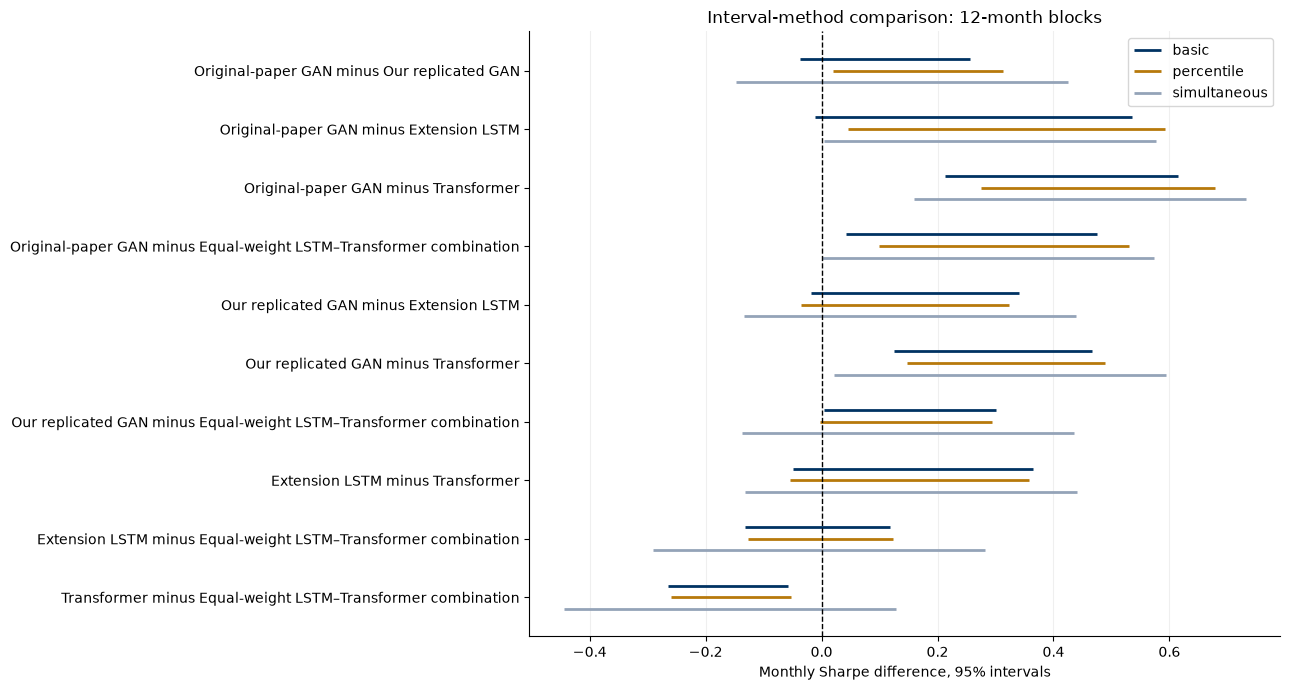

In [6]:
def interval_status(lower, upper):
    return np.where(lower > 0, 'A higher', np.where(upper < 0, 'B higher', 'Unresolved'))

method_comparison = pair_ci[['block_months', 'model_a', 'model_b', 'difference_a_minus_b']].copy()
for method, lo, hi in [('basic', 'basic_lower', 'basic_upper'),
                       ('percentile', 'percentile_lower', 'percentile_upper'),
                       ('simultaneous', 'simultaneous_lower', 'simultaneous_upper')]:
    method_comparison[method + '_status'] = interval_status(pair_ci[lo], pair_ci[hi])
    method_comparison[method + '_width'] = pair_ci[hi] - pair_ci[lo]
method_comparison['basic_percentile_agree'] = method_comparison.basic_status == method_comparison.percentile_status
method_comparison.to_csv(OUT / 'tables/interval_method_comparison.csv', index=False)
display(Markdown('### Primary 12-month analysis: interval-method conclusions'))
display(method_comparison[method_comparison.block_months == 12][
    ['model_a', 'model_b', 'difference_a_minus_b', 'basic_status', 'percentile_status', 'simultaneous_status']])
robustness = method_comparison.groupby(['model_a', 'model_b']).agg(
    basic_excludes_zero_choices=('basic_status', lambda z: int((z != 'Unresolved').sum())),
    percentile_excludes_zero_choices=('percentile_status', lambda z: int((z != 'Unresolved').sum())),
    simultaneous_excludes_zero_choices=('simultaneous_status', lambda z: int((z != 'Unresolved').sum())),
    interval_method_disagreements=('basic_percentile_agree', lambda z: int((~z).sum()))).reset_index()
robustness['block_choices'] = len(CONFIG['block_lengths'])
robustness.to_csv(OUT / 'tables/comparison_robustness.csv', index=False)
display(Markdown('### All pairs: number of block choices whose intervals exclude zero'))
display(robustness)
method_notes = []
for r in method_comparison[method_comparison.block_months == 12].itertuples():
    method_notes.append(f'- **{r.model_a} minus {r.model_b}:** basic: {r.basic_status}; percentile: {r.percentile_status}; simultaneous: {r.simultaneous_status}.')
display(Markdown('**Part 6 answer:**\n\n' + '\n'.join(method_notes)))
fig, ax = plt.subplots(figsize=(13, 7))
methods = [('basic', 'basic_lower', 'basic_upper', '#003262'),
           ('percentile', 'percentile_lower', 'percentile_upper', '#B7790B'),
           ('simultaneous', 'simultaneous_lower', 'simultaneous_upper', '#94A3B8')]
for offset, (method, lo, hi, color) in zip([-.2, 0, .2], methods):
    for j, r in enumerate(primary_pairs.to_dict('records')):
        ax.hlines(j + offset, r[lo], r[hi], color=color, lw=2, label=method if j == 0 else None)
ax.set_yticks(range(10), [f'{NAMES[i]} minus {NAMES[j]}' for i, j in PAIRS]); ax.invert_yaxis()
ax.axvline(0, color='black', ls='--', lw=1); ax.set_xlabel('Monthly Sharpe difference, 95% intervals')
ax.set_title('Interval-method comparison: 12-month blocks'); ax.legend(); ax.grid(axis='x', alpha=.2)
fig.tight_layout(); fig.savefig(OUT / 'figures/interval_method_comparison.png', dpi=170); fig.savefig(OUT / 'figures/interval_method_comparison.pdf', bbox_inches='tight'); plt.show()

### Part 6 interpretation — Method agreement and disagreement

**Basic interval:** If the observed difference is d and bootstrap quantiles are q_low and q_high, the interval is [2d − q_high, 2d − q_low]. It reflects the bootstrap error around the observed value.

**Percentile interval:** This is [q_low, q_high]. It uses the bootstrap estimates directly. Basic and percentile intervals have the same width for the same draws, but can be centered differently. Therefore their zero-exclusion conclusions can differ.

**Status columns:** “A higher” means the relevant interval lies above zero; “B higher” means it lies below zero; “Unresolved” means it includes zero. These labels summarize approximate interval evidence and are not universal model rankings.

**Actual disagreement:** Authors versus Code 07 excludes zero under percentile intervals at all three block lengths, but under basic intervals at none. Report this sensitivity instead of choosing the favorable method. Authors versus Transformer and Code 07 versus Transformer exclude zero under all three methods across all three block lengths. These latter comparisons are more consistent across the examined settings, although their models have different training procedures.

**Robustness counts:** A count of 3 means all three chosen lengths; it is not three independent statistical tests confirming the hypothesis. A count of 0 means no selected interval excludes zero, not proof of equality.

**Answer:** Method sensitivity is itself a substantive result. Simultaneous intervals are calibrated differently and need not contain every basic or percentile interval.

## Part 7 — Dependence diagnostic: independent months versus blocks
**Explanation:** A block of length one independently resamples months. It preserves contemporaneous
pairing but removes serial dependence. This is a diagnostic benchmark, not our recommended time-series
inference. Its interval may be narrower or wider than the block interval; the direction is empirical.
**Questions:** How much does ignoring serial dependence change the reported uncertainty?
**Answer:** Compare widths and zero-crossing conclusions below. A narrower IID interval is not evidence
that the IID procedure is more accurate. All existing full-test and training limitations remain.

,model_a,model_b,difference,iid_basic_lower,iid_basic_upper,block12_basic_lower,block12_basic_upper,iid_width,block12_width,iid_status,block12_status,block12_to_iid_width_ratio
0,Original-paper GAN,Our replicated GAN,0.138033,-0.001378,0.248344,-0.036797,0.255664,0.249723,0.292462,Unresolved,Unresolved,1.171146
1,Original-paper GAN,Extension LSTM,0.290627,0.065421,0.490452,-0.011909,0.536113,0.425032,0.548022,A higher,Unresolved,1.289367
2,Original-paper GAN,Transformer,0.445443,0.254589,0.615874,0.212575,0.615292,0.361284,0.402717,A higher,A higher,1.114683
3,Original-paper GAN,Equal-weight LSTM–Transformer combination,0.286817,0.100885,0.450262,0.042862,0.475137,0.349377,0.432275,A higher,A higher,1.237275
4,Our replicated GAN,Extension LSTM,0.152594,0.005043,0.305563,-0.017560,0.340309,0.300520,0.357868,A higher,Unresolved,1.190829
5,Our replicated GAN,Transformer,0.307411,0.136700,0.457478,0.125750,0.466905,0.320778,0.341155,A higher,A higher,1.063527
6,Our replicated GAN,Equal-weight LSTM–Transformer combination,0.148785,0.017462,0.272223,0.003375,0.300668,0.254760,0.297293,A higher,A higher,1.166951
7,Extension LSTM,Transformer,0.154816,-0.041551,0.346651,-0.048955,0.364925,0.388203,0.413880,Unresolved,Unresolved,1.066143
8,Extension LSTM,Equal-weight LSTM–Transformer combination,-0.003810,-0.122583,0.103030,-0.131614,0.118783,0.225613,0.250397,Unresolved,Unresolved,1.109853
9,Transformer,Equal-weight LSTM–Transformer combination,-0.158626,-0.257902,-0.061851,-0.264556,-0.057061,0.196051,0.207495,B higher,B higher,1.058372


**Part 7 answer:** The table compares uncertainty from independent-month resampling with 12-month blocks. Interpret any changed conclusion as dependence sensitivity, not a reason to choose the more favorable method.

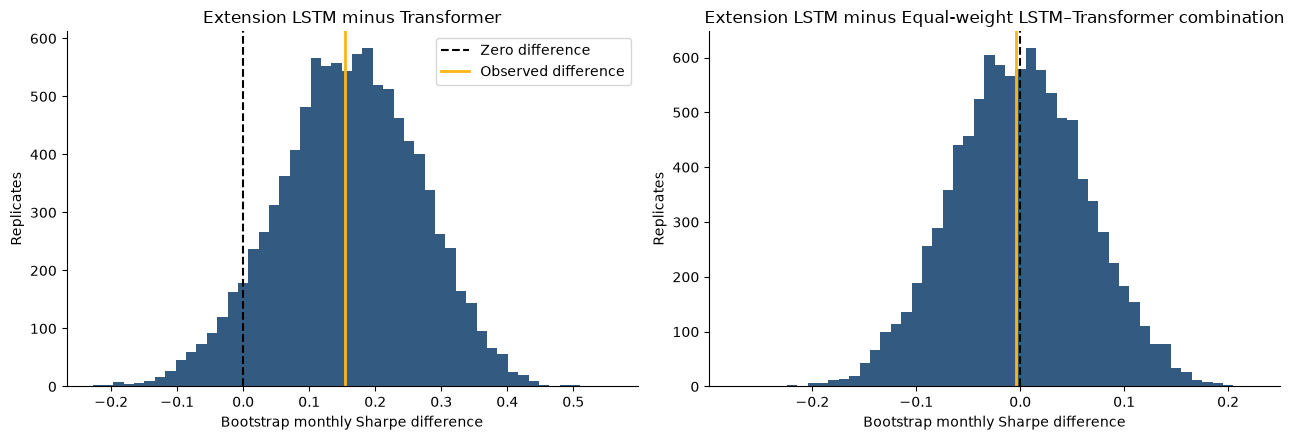

In [7]:
iid_draws = bootstrap_sharpes(X, 1, CONFIG['replicates'],
    np.random.SeedSequence([CONFIG['random_seed'], 1]), CONFIG['batch_size'])
iid_rows = []
for i, j in PAIRS:
    d = point[i] - point[j]
    qlo, qhi = np.quantile(iid_draws[:, i] - iid_draws[:, j], [.025, .975])
    ref = primary_pairs[(primary_pairs.model_a == NAMES[i]) & (primary_pairs.model_b == NAMES[j])].iloc[0]
    lo, hi = 2 * d - qhi, 2 * d - qlo
    iid_rows.append(dict(model_a=NAMES[i], model_b=NAMES[j], difference=d,
        iid_basic_lower=lo, iid_basic_upper=hi, block12_basic_lower=ref.basic_lower,
        block12_basic_upper=ref.basic_upper, iid_width=hi-lo,
        block12_width=ref.basic_upper-ref.basic_lower,
        iid_status=interval_status(np.array([lo]), np.array([hi]))[0],
        block12_status=interval_status(np.array([ref.basic_lower]), np.array([ref.basic_upper]))[0]))
iid_comparison = pd.DataFrame(iid_rows)
iid_comparison['block12_to_iid_width_ratio'] = iid_comparison.block12_width / iid_comparison.iid_width
iid_comparison.to_csv(OUT / 'tables/iid_vs_block_diagnostic.csv', index=False)
display(iid_comparison)
display(Markdown('**Part 7 answer:** The table compares uncertainty from independent-month resampling with 12-month blocks. Interpret any changed conclusion as dependence sensitivity, not a reason to choose the more favorable method.'))
fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, (a, b) in zip(axs, [('Extension LSTM', 'Transformer'), ('Extension LSTM', 'Equal-weight LSTM–Transformer combination')]):
    i, j = NAMES.index(a), NAMES.index(b)
    ax.hist(draws[12][:, i] - draws[12][:, j], bins=50, color='#003262', alpha=.8)
    ax.axvline(0, color='black', ls='--', label='Zero difference')
    ax.axvline(point[i]-point[j], color='#FDB515', lw=2, label='Observed difference')
    ax.set_title(f'{a} minus {b}'); ax.set_xlabel('Bootstrap monthly Sharpe difference'); ax.set_ylabel('Replicates')
axs[0].legend(); fig.tight_layout(); fig.savefig(OUT / 'figures/bootstrap_difference_distributions.png', dpi=170); fig.savefig(OUT / 'figures/bootstrap_difference_distributions.pdf', bbox_inches='tight'); plt.show()

### Part 7 interpretation — What the IID diagnostic adds

**IID benchmark:** Length-one blocks resample independent months while keeping the five portfolios paired. This removes time dependence, making it a useful diagnostic against the primary block procedure rather than our preferred time-series method.

**Read the width ratio.** A ratio above one means the 12-month basic interval is wider than its IID counterpart. For LSTM minus Transformer, the widths are approximately 0.414 versus 0.388: a ratio of 1.066. For LSTM minus blend, they are 0.250 versus 0.226: a ratio of 1.110. Both comparisons remain unresolved under both procedures.

**Histograms:** These show the distribution of resampled differences. The gold line is the observed difference and the dashed black line is zero. Values on both sides illustrate uncertainty in the direction. The fraction of draws above zero is not automatically a valid p-value or the probability that one model is truly superior.

**Answer:** Dependence treatment affects estimated precision. In these two comparisons it does not change the basic-interval conclusion. That does not prove serial dependence is absent or the IID assumption is valid.

## Part 8 — Monthly versus annualized units, and uncertainty in interval widths
**Explanation:** Multiplication by sqrt(12) rescales every estimate and interval endpoint by the same
positive constant. It cannot change whether zero is inside a difference interval. A larger annualized
number does not create stronger statistical evidence. Interval width and bootstrap standard error describe
different summaries of the resampled distribution; neither measures variability across retrained models.
**Questions:** Does annualization change conclusions? Which models have wider intervals? Does block
length affect estimated precision? **Answer:** The tables below show units and width sensitivity explicitly.

In [8]:
units = primary_models[['model', 'monthly_sharpe', 'basic_lower', 'basic_upper',
    'annualized_monthly_sharpe', 'annualized_basic_lower', 'annualized_basic_upper']].copy()
units = units.rename(columns={'annualized_monthly_sharpe': 'annualized_sharpe'})
units.to_csv(OUT / 'tables/monthly_vs_annualized_intervals.csv', index=False)
display(units)
widths = model_ci[['model', 'block_months', 'bootstrap_se']].copy()
widths['basic_interval_width'] = model_ci.basic_upper - model_ci.basic_lower
widths['percentile_interval_width'] = model_ci.percentile_upper - model_ci.percentile_lower
widths.to_csv(OUT / 'tables/model_precision_sensitivity.csv', index=False)
display(widths.pivot(index='model', columns='block_months', values='basic_interval_width'))
assert np.array_equal(primary_pairs.basic_lower > 0, primary_pairs.annualized_basic_lower > 0)
assert np.array_equal(primary_pairs.basic_upper < 0, primary_pairs.annualized_basic_upper < 0)
display(Markdown('**Part 8 answer:** Annualization changes units only; every zero-exclusion conclusion is unchanged. Width comparisons describe return-sample precision for fixed models, not which model is economically best or most stable across training seeds.'))

,model,monthly_sharpe,basic_lower,basic_upper,annualized_sharpe,annualized_basic_lower,annualized_basic_upper
5,Original-paper GAN,0.749920,0.442040,0.972515,2.597799,1.531272,3.368890
6,Our replicated GAN,0.611888,0.379625,0.783478,2.119641,1.315060,2.714048
7,Extension LSTM,0.459293,0.243634,0.625765,1.591039,0.843973,2.167714
8,Transformer,0.304477,0.145547,0.439330,1.054739,0.504189,1.521883
9,Equal-weight LSTM–Transformer combination,0.463103,0.265025,0.612491,1.604236,0.918075,2.121730


block_months,6,12,24
model,,,
Equal-weight LSTM–Transformer combination,0.339701,0.347465,0.372734
Extension LSTM,0.364801,0.382131,0.376025
Original-paper GAN,0.456876,0.530475,0.607512
Our replicated GAN,0.372598,0.403853,0.425381
Transformer,0.295502,0.293783,0.309363


**Part 8 answer:** Annualization changes units only; every zero-exclusion conclusion is unchanged. Width comparisons describe return-sample precision for fixed models, not which model is economically best or most stable across training seeds.

### Part 8 interpretation — Units, standard errors, and precision

**Annualization:** LSTM monthly Sharpe 0.459 becomes approximately 1.591 after multiplication by √12. Its interval endpoints are multiplied by the same number. Positive scaling cannot change whether zero is inside an interval, so annualization cannot strengthen statistical evidence.

**Standard error:** `bootstrap_se` is the standard deviation of the resampled Sharpe estimates. It estimates variability of the statistic, not volatility of monthly returns and not variation across training seeds.

**Interval width:** Upper minus lower measures precision on the stated scale. Basic and percentile widths are equal by construction here; their centers can differ. Comparisons across block lengths assess how the assumed dependence horizon affects uncertainty. Longer blocks need not always create wider intervals.

**Answer:** Distinguish return volatility, uncertainty about Sharpe, and uncertainty across trained models. This notebook measures the second. Conventional annualization here is not an autocorrelation-adjusted long-horizon Sharpe calculation.

## Part 9 — What belongs in the paper, and what remains open?
**Question:** Can we now state that LSTM is better than Transformer?
**Answer:** LSTM has higher observed Sharpe in this reduced-budget experiment, but its paired full-test
interval includes zero across the examined block lengths. We cannot conclude equivalence either.
**Question:** Does overlap with the original authors validate exact replication?
**Answer:** No. Failing to resolve a difference is not proof of replication; code conventions, training
budgets, data definitions, and pricing diagnostics must also be checked.
**Question:** Are the blend and historical benchmarks directly controlled comparisons?
**Answer:** The new LSTM and Transformer share the reduced schedule. Author and Code 07 models use
different procedures, and the blend was constructed after viewing test outcomes. Inference is conditional
on these fixed portfolios and does not remove those design differences.
**Question:** What should follow Code 012?
**Answer:** Verify holdings/identifiers before turnover and transaction costs; separately consider full
matched training and a genuinely unexamined evaluation period. No such experiment is performed here.

In [9]:
extra = '\n\n## Additional interval-method comparisons (12-month blocks)\n\n' + '\n'.join(method_notes)
extra += '\n\n## Additional comparisons\n\nTables include all ten pairs across three block lengths, IID-versus-block diagnostics, monthly-versus-annualized intervals, and model precision sensitivity. IID is a dependence diagnostic only. Method disagreement must be reported rather than resolved by choosing the favorable interval. Annualization leaves zero-crossing conclusions unchanged.'
(OUT / 'results_and_answers.md').write_text(answers + extra)
manifest['additional_diagnostics'] = {'iid_block_length': 1, 'iid_replicates': CONFIG['replicates'],
    'iid_seed_components': [CONFIG['random_seed'], 1],
    'comparisons': ['interval methods', 'block-length robustness', 'IID versus blocks', 'monthly versus annualized', 'precision sensitivity']}
(OUT / 'manifest.json').write_text(json.dumps(manifest, indent=2))
display(Markdown('**Saved:** Expanded notebook answers, five comparison tables in addition to the original tables, and two additional figures. No models were retrained.'))

**Saved:** Expanded notebook answers, five comparison tables in addition to the original tables, and two additional figures. No models were retrained.

### Part 9 interpretation — Scope of the contribution

**What this adds:** A reproducible uncertainty assessment for five fixed portfolios and their ten pairwise Sharpe differences, with explicit dependence, interval-method, and multiplicity comparisons. It helps prevent treating every numerical ranking as an established performance difference.

**What remains conditional:** The original test period has already informed earlier comparisons. Fixed-model resampling does not account for choosing architectures, checkpoints, blend construction, or research directions after examining outcomes. Simultaneous intervals address only the ten displayed differences within a single chosen bootstrap setting.

**Economic versus statistical meaning:** A small difference can be economically interesting but imprecisely estimated. A statistically resolved gross-Sharpe difference need not survive transaction costs or investment constraints. Neither result proves that the model prices every asset correctly; pricing errors require separate diagnostics.

**Answer and next step:** Keep observed performance, uncertainty, and implementation feasibility as separate claims. Transaction-cost work requires reliable holdings and identifiers. Full matched training and a genuinely unexamined evaluation period address different limitations. Code 012 performs neither experiment.

## Part 10 — Bootstrap uncertainty within rolling windows

**Purpose and questions:** Does the observed architecture advantage remain clear within 36- or
60-month periods? How do the original-paper GAN, our replication, and the equal-weight combination
compare? Does changing the local block length alter selected endpoint conclusions?

**Process:** At every complete endpoint, take the underlying 36 or 60 monthly return rows, resample
paired circular blocks within that window, and recompute all five Sharpes and ten paired differences.
We use 2,000 draws, six-month blocks, and deterministic seeds for every window. At December endpoints,
also examine three- and twelve-month blocks. These are illustrative choices, not optimized settings.
All estimates and interval endpoints below are annualized by sqrt(12).

**How to read:** A shaded model interval describes uncertainty about Sharpe within that window.
A paired-difference interval crossing zero leaves the direction unresolved. Simultaneous intervals
adjust for the ten pairs within one window only. Neither these intervals nor the pointwise bands
provide a simultaneous confidence band across the entire timeline. Adjacent windows overlap heavily.
Counts of zero-excluding windows are descriptive counts, not independent tests or probabilities.

**Limits:** Thirty-six observations provide little information about dependence or tails. With
twelve-month blocks, a 36-month sample has only three resampled blocks. Local stationarity remains
an assumption; circular wrapping joins the window's end to its beginning artificially. The fixed
portfolios may have been fitted before the window, and no rolling refits are performed. This is
conditional uncertainty for saved-model returns, not a new real-time backtest.

In [10]:
ROLLING_CONFIG = dict(window_months=[36, 60], primary_block_months=6, replicates=2000,
    selected_endpoint_sensitivity_blocks=[3, 12], sensitivity_endpoints='December only', seed=20261006)
rolling_models, rolling_pairs = [], []
for window in ROLLING_CONFIG['window_months']:
    for endpoint in range(window - 1, len(X)):
        sample = X[endpoint-window+1:endpoint+1]
        date = returns.index[endpoint]
        lengths = [6] + ([3, 12] if date.month == 12 else [])
        observed = sharpe(sample)
        delta = np.array([observed[i]-observed[j] for i,j in PAIRS])
        for length in lengths:
            bs = bootstrap_sharpes(sample, length, ROLLING_CONFIG['replicates'],
                np.random.SeedSequence([ROLLING_CONFIG['seed'], window, endpoint, length]))
            lo, hi = np.quantile(bs, [.025,.975], axis=0)
            for j, model in enumerate(NAMES):
                rolling_models.append(dict(date=date, window_months=window, block_months=length,
                    model=model, annualized_sharpe=observed[j]*np.sqrt(12),
                    basic_lower=(2*observed[j]-hi[j])*np.sqrt(12),
                    basic_upper=(2*observed[j]-lo[j])*np.sqrt(12)))
            bd = np.column_stack([bs[:,i]-bs[:,j] for i,j in PAIRS])
            qlo, qhi = np.quantile(bd,[.025,.975],axis=0)
            critical = np.quantile(np.max(np.abs(bd-delta),axis=1),.95)
            for k,(i,j) in enumerate(PAIRS):
                low, high = (2*delta[k]-qhi[k])*np.sqrt(12), (2*delta[k]-qlo[k])*np.sqrt(12)
                sl, sh = (delta[k]-critical)*np.sqrt(12),(delta[k]+critical)*np.sqrt(12)
                rolling_pairs.append(dict(date=date,window_months=window,block_months=length,
                    model_a=NAMES[i],model_b=NAMES[j],annualized_difference=delta[k]*np.sqrt(12),
                    basic_lower=low,basic_upper=high,simultaneous_lower=sl,simultaneous_upper=sh,
                    pointwise_direction='A higher' if low>0 else 'B higher' if high<0 else 'Unresolved',
                    simultaneous_direction='A higher' if sl>0 else 'B higher' if sh<0 else 'Unresolved'))
    print('Completed rolling uncertainty:',window,'months')
rolling_model_ci=pd.DataFrame(rolling_models)
rolling_pair_ci=pd.DataFrame(rolling_pairs)
rolling_model_ci.to_csv(OUT/'tables/rolling_model_sharpe_intervals.csv',index=False)
rolling_pair_ci.to_csv(OUT/'tables/rolling_paired_difference_intervals.csv',index=False)
primary_rolling=rolling_pair_ci[rolling_pair_ci.block_months==6]
assert primary_rolling.groupby('window_months').date.nunique().to_dict()=={36:265,60:241}
count_rows=[]
for (window,a,b),q in primary_rolling.groupby(['window_months','model_a','model_b']):
    count_rows.append(dict(window_months=window,model_a=a,model_b=b,overlapping_windows=len(q),
        observed_a_higher=int((q.annualized_difference>0).sum()),
        basic_a_higher=int((q.pointwise_direction=='A higher').sum()),
        basic_b_higher=int((q.pointwise_direction=='B higher').sum()),
        basic_unresolved=int((q.pointwise_direction=='Unresolved').sum()),
        simultaneous_unresolved=int((q.simultaneous_direction=='Unresolved').sum())))
rolling_counts=pd.DataFrame(count_rows)
rolling_counts.to_csv(OUT/'tables/rolling_comparison_counts.csv',index=False)
display(Markdown('### Descriptive counts across overlapping windows — six-month blocks'))
display(rolling_counts)
display(Markdown('### Latest window: all ten paired comparisons, annualized units'))
display(primary_rolling[primary_rolling.date==returns.index[-1]][['window_months','model_a','model_b',
    'annualized_difference','basic_lower','basic_upper','simultaneous_direction']])
# Verify point estimates exactly match Code 11, allowing only floating-point round-off.
previous=pd.read_csv(ROOT/'results/consolidated_comparison/tables/official_extended_rolling_series.csv',parse_dates=['date'])
for w in [36,60]:
    current=rolling_model_ci[(rolling_model_ci.window_months==w)&(rolling_model_ci.block_months==6)]
    for source_name,display_name in zip(SOURCE_NAMES,NAMES):
        old=previous[previous.window_months==w].set_index('date')[source_name].dropna()
        new=current[current.model==display_name].set_index('date').annualized_sharpe
        np.testing.assert_allclose(new.loc[old.index],old,atol=1e-10)
print('Rolling point estimates match Code 11. No retraining.')

Completed rolling uncertainty: 36 months


Completed rolling uncertainty: 60 months


### Descriptive counts across overlapping windows — six-month blocks

,window_months,model_a,model_b,overlapping_windows,observed_a_higher,basic_a_higher,basic_b_higher,basic_unresolved,simultaneous_unresolved
0,36,Extension LSTM,Equal-weight LSTM–Transformer combination,265,128,5,26,234,265
1,36,Extension LSTM,Transformer,265,168,39,0,226,259
2,36,Original-paper GAN,Equal-weight LSTM–Transformer combination,265,220,93,0,172,194
3,36,Original-paper GAN,Extension LSTM,265,206,83,1,181,206
4,36,Original-paper GAN,Our replicated GAN,265,208,63,0,202,255
5,36,Original-paper GAN,Transformer,265,258,129,0,136,162
6,36,Our replicated GAN,Equal-weight LSTM–Transformer combination,265,184,54,20,191,244
7,36,Our replicated GAN,Extension LSTM,265,215,65,2,198,263
8,36,Our replicated GAN,Transformer,265,225,58,6,201,217
9,36,Transformer,Equal-weight LSTM–Transformer combination,265,11,0,73,192,265


### Latest window: all ten paired comparisons, annualized units

,window_months,model_a,model_b,annualized_difference,basic_lower,basic_upper,simultaneous_direction
3080,36,Original-paper GAN,Our replicated GAN,-0.100865,-0.475303,0.773498,Unresolved
3081,36,Original-paper GAN,Extension LSTM,0.577404,-0.304691,1.399626,Unresolved
3082,36,Original-paper GAN,Transformer,0.325814,-0.508437,2.223182,Unresolved
3083,36,Original-paper GAN,Equal-weight LSTM–Transformer combination,0.258555,-0.420010,2.189005,Unresolved
3084,36,Our replicated GAN,Extension LSTM,0.678269,-0.728926,1.447055,Unresolved
3085,36,Our replicated GAN,Transformer,0.426679,-0.291811,1.619108,Unresolved
3086,36,Our replicated GAN,Equal-weight LSTM–Transformer combination,0.359420,-0.184076,1.658311,Unresolved
3087,36,Extension LSTM,Transformer,-0.251590,-1.254048,1.641227,Unresolved
3088,36,Extension LSTM,Equal-weight LSTM–Transformer combination,-0.318849,-1.053762,1.715911,Unresolved
3089,36,Transformer,Equal-weight LSTM–Transformer combination,-0.067259,-0.349661,0.383163,Unresolved


Rolling point estimates match Code 11. No retraining.


### Rolling figures and interpretation
**Model panels:** Each row is one portfolio; left and right columns use different window lengths.
Compare the line with its own shaded basic interval, not with another portfolio's separate interval.
**Difference panels:** These directly compare paired strategies. The shaded bands are pointwise basic
intervals. They do not establish significance for a whole historical period or identify causal regimes.
**Endpoint sensitivity:** December-only tables compare alternative block lengths without choosing the
setting that gives the strongest finding. The latest endpoint is shown to make the units concrete.

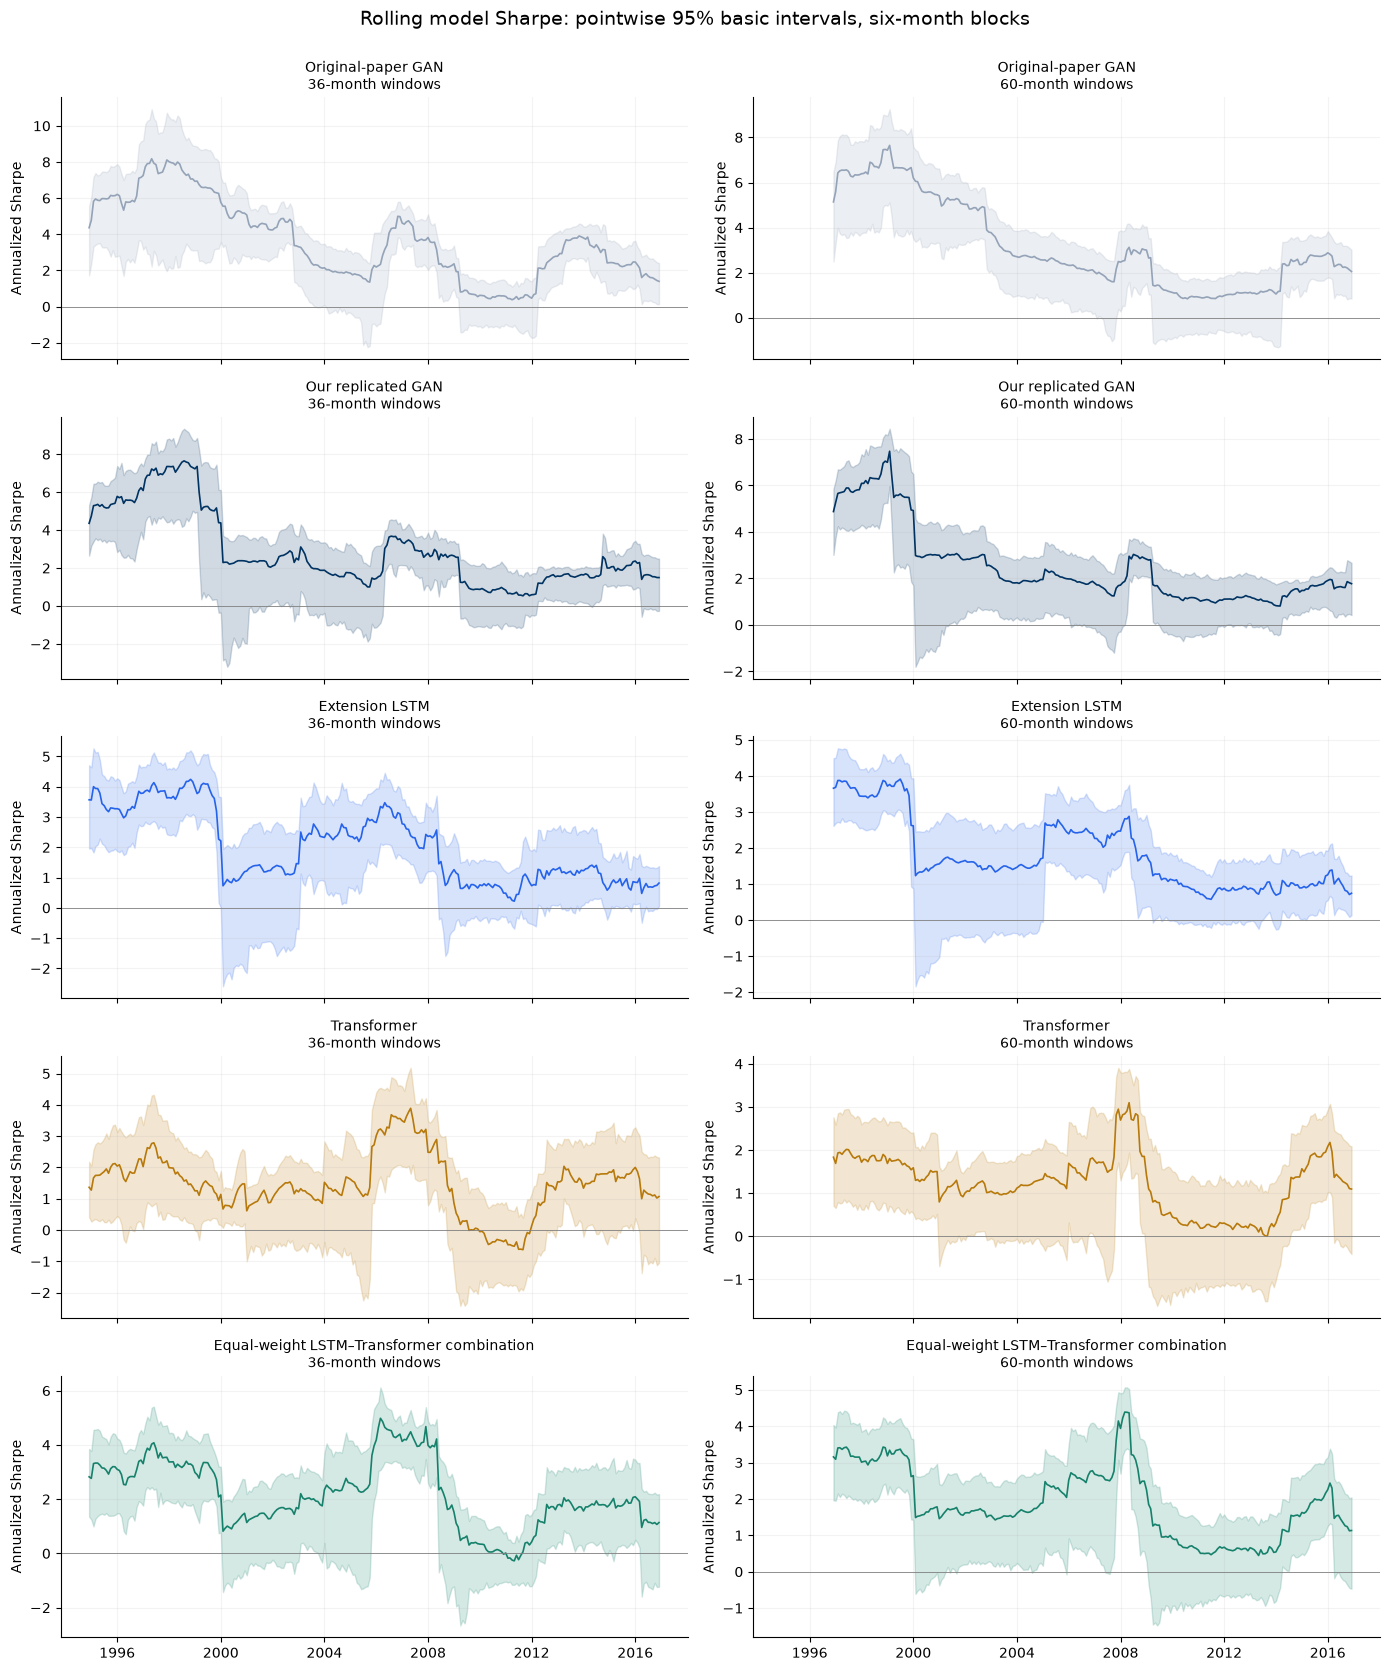

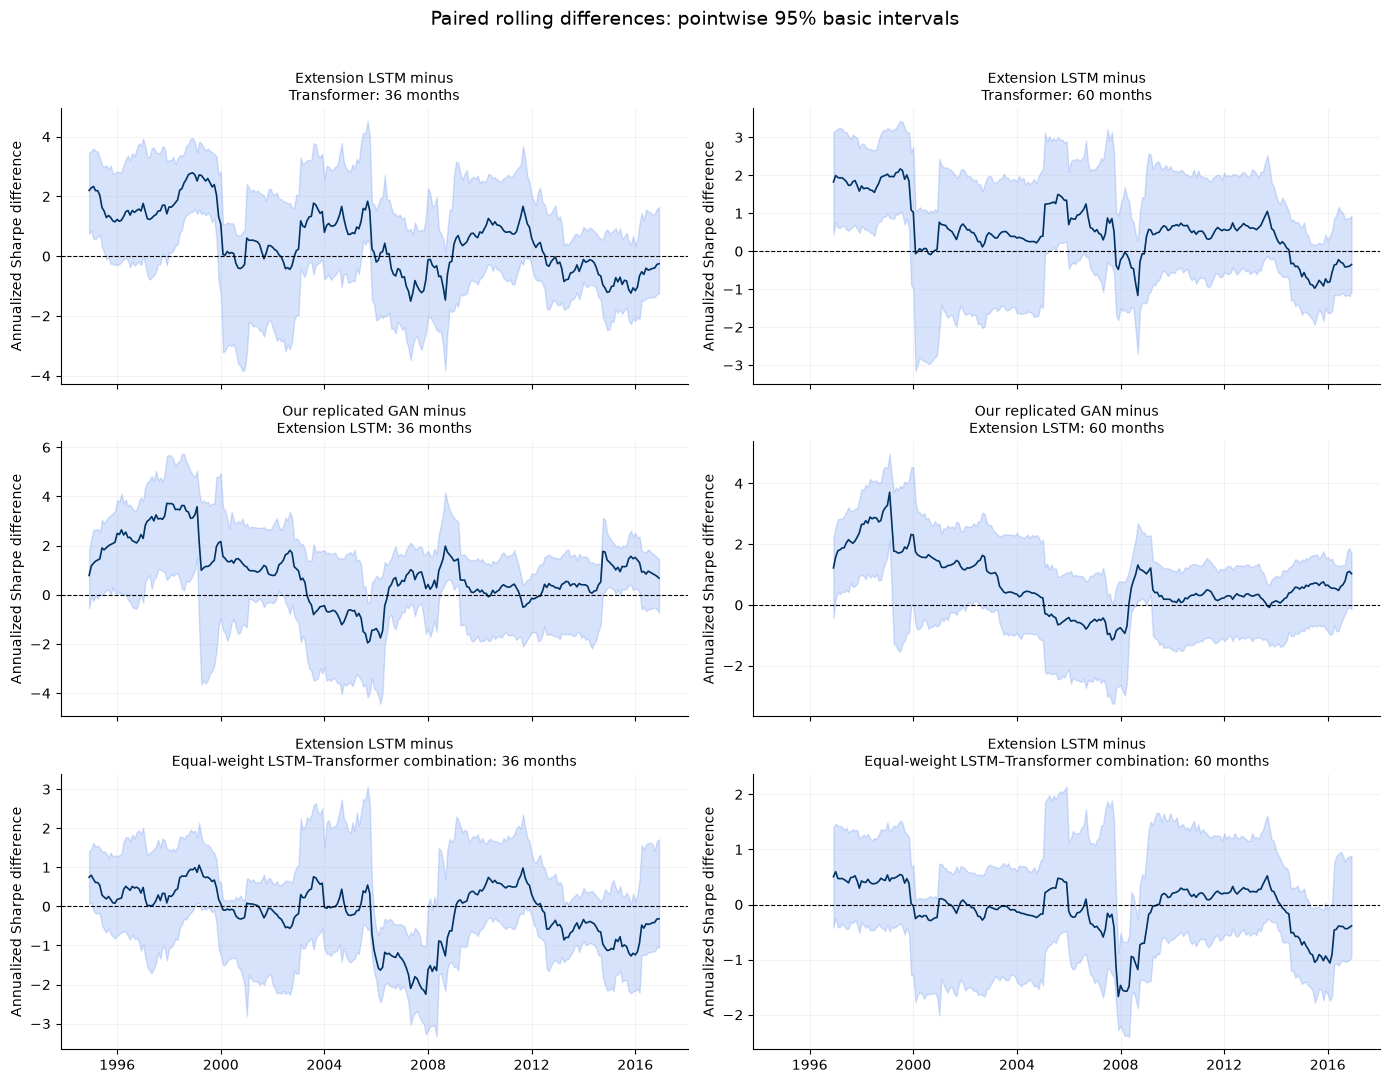

### Architecture comparison: latest December endpoint and block sensitivity

,window_months,block_months,annualized_difference,basic_lower,basic_upper,simultaneous_direction
3087,36,6,-0.251590,-1.254048,1.641227,Unresolved
3097,36,3,-0.251590,-1.285117,1.431516,Unresolved
3107,36,12,-0.251590,-1.364150,1.735478,Unresolved
5917,60,6,-0.349753,-1.077453,0.935306,Unresolved
5927,60,3,-0.349753,-1.073792,0.845101,Unresolved
5937,60,12,-0.349753,-1.123038,0.864444,Unresolved


## Rolling uncertainty — results and interpretation

- All 265 complete 36-month windows and 241 complete 60-month windows are analyzed without retraining.
- Figures show pointwise basic intervals. Simultaneous table intervals adjust for ten pairs within each window, not across dates.
- **36 months, LSTM minus Transformer:** LSTM has higher observed Sharpe in 168/265 windows. Basic intervals favor LSTM in 39, favor Transformer in 0, and leave 226 unresolved. These overlapping counts are descriptive, not independent evidence.
- **60 months, LSTM minus Transformer:** LSTM has higher observed Sharpe in 193/241 windows. Basic intervals favor LSTM in 45, favor Transformer in 0, and leave 196 unresolved. These overlapping counts are descriptive, not independent evidence.
- Larger or smaller point estimates should be interpreted with their window-specific intervals. Short windows have limited information; apparent performance changes need not be precisely estimated.
- Three-, six-, and twelve-month block comparisons at December endpoints assess local sensitivity. They do not select a model or define a trading signal.
- Labels now distinguish the original-paper GAN, our replicated GAN, the extension architectures, and the equal-weight LSTM–Transformer combination.

5532

In [11]:
fig,axs=plt.subplots(5,2,figsize=(14,17),sharex=True)
for row,(name,color) in enumerate(zip(NAMES,COLORS)):
    for col,w in enumerate([36,60]):
        q=rolling_model_ci[(rolling_model_ci.window_months==w)&(rolling_model_ci.block_months==6)&(rolling_model_ci.model==name)].sort_values('date')
        ax=axs[row,col];ax.plot(q.date,q.annualized_sharpe,color=color,lw=1.2)
        ax.fill_between(q.date,q.basic_lower,q.basic_upper,color=color,alpha=.18)
        ax.axhline(0,color='gray',lw=.6);ax.set_title(f'{name}\n{w}-month windows',fontsize=10)
        ax.set_ylabel('Annualized Sharpe');ax.grid(alpha=.15)
fig.suptitle('Rolling model Sharpe: pointwise 95% basic intervals, six-month blocks',fontsize=14)
fig.tight_layout(rect=[0,0,1,.98]);fig.savefig(OUT/'figures/rolling_model_uncertainty.png',dpi=150); fig.savefig(OUT / 'figures/rolling_model_uncertainty.pdf', bbox_inches='tight');plt.show()
focus=[(NAMES[2],NAMES[3]),(NAMES[1],NAMES[2]),(NAMES[2],NAMES[4])]
fig,axs=plt.subplots(3,2,figsize=(14,11),sharex=True)
for row,(a,b) in enumerate(focus):
    for col,w in enumerate([36,60]):
        q=primary_rolling[(primary_rolling.window_months==w)&(primary_rolling.model_a==a)&(primary_rolling.model_b==b)].sort_values('date')
        ax=axs[row,col];ax.fill_between(q.date,q.basic_lower,q.basic_upper,color='#2563EB',alpha=.18)
        ax.plot(q.date,q.annualized_difference,color='#003262',lw=1.2)
        ax.axhline(0,color='black',ls='--',lw=.8)
        ax.set_title(f'{a} minus\n{b}: {w} months',fontsize=10);ax.set_ylabel('Annualized Sharpe difference');ax.grid(alpha=.15)
fig.suptitle('Paired rolling differences: pointwise 95% basic intervals',fontsize=14)
fig.tight_layout(rect=[0,0,1,.97]);fig.savefig(OUT/'figures/rolling_difference_uncertainty.png',dpi=150); fig.savefig(OUT / 'figures/rolling_difference_uncertainty.pdf', bbox_inches='tight');plt.show()
sensitivity=rolling_pair_ci[(rolling_pair_ci.date.dt.month==12)&(rolling_pair_ci.model_a==NAMES[2])&
    (rolling_pair_ci.model_b==NAMES[3])].copy()
sensitivity.to_csv(OUT/'tables/rolling_architecture_december_sensitivity.csv',index=False)
display(Markdown('### Architecture comparison: latest December endpoint and block sensitivity'))
display(sensitivity[sensitivity.date==returns.index[-1]][['window_months','block_months',
    'annualized_difference','basic_lower','basic_upper','simultaneous_direction']])
rolling_lines=['## Rolling uncertainty — results and interpretation','',
    '- All 265 complete 36-month windows and 241 complete 60-month windows are analyzed without retraining.',
    '- Figures show pointwise basic intervals. Simultaneous table intervals adjust for ten pairs within each window, not across dates.']
for w in [36,60]:
    r=rolling_counts[(rolling_counts.window_months==w)&(rolling_counts.model_a==NAMES[2])&
        (rolling_counts.model_b==NAMES[3])].iloc[0]
    rolling_lines.append(f'- **{w} months, LSTM minus Transformer:** LSTM has higher observed Sharpe in {r.observed_a_higher}/{r.overlapping_windows} windows. Basic intervals favor LSTM in {r.basic_a_higher}, favor Transformer in {r.basic_b_higher}, and leave {r.basic_unresolved} unresolved. These overlapping counts are descriptive, not independent evidence.')
rolling_lines+=['- Larger or smaller point estimates should be interpreted with their window-specific intervals. Short windows have limited information; apparent performance changes need not be precisely estimated.',
    '- Three-, six-, and twelve-month block comparisons at December endpoints assess local sensitivity. They do not select a model or define a trading signal.',
    '- Labels now distinguish the original-paper GAN, our replicated GAN, the extension architectures, and the equal-weight LSTM–Transformer combination.']
rolling_answer='\n'.join(rolling_lines)
(OUT/'rolling_results_and_answers.md').write_text(rolling_answer)
display(Markdown(rolling_answer))
manifest['rolling_analysis']=ROLLING_CONFIG
manifest['display_name_mapping']=dict(zip(SOURCE_NAMES,NAMES))
(OUT/'manifest.json').write_text(json.dumps(manifest,indent=2))
# Regenerate the combined written answers, including this section.
(OUT/'results_and_answers.md').write_text(answers+extra+'\n\n'+rolling_answer)

## Saved figure names and files

| Figure | Name | PNG | PDF |
|---|---|---|---|
| 1 | Full-test model Sharpe confidence intervals | [PNG](../results/bootstrap_uncertainty/figures/model_sharpe_intervals.png) | [PDF](../results/bootstrap_uncertainty/figures/model_sharpe_intervals.pdf) |
| 2 | Full-test paired Sharpe differences | [PNG](../results/bootstrap_uncertainty/figures/paired_difference_intervals.png) | [PDF](../results/bootstrap_uncertainty/figures/paired_difference_intervals.pdf) |
| 3 | Block-length sensitivity for architecture and combination | [PNG](../results/bootstrap_uncertainty/figures/block_length_sensitivity.png) | [PDF](../results/bootstrap_uncertainty/figures/block_length_sensitivity.pdf) |
| 4 | Basic, percentile, and simultaneous interval comparison | [PNG](../results/bootstrap_uncertainty/figures/interval_method_comparison.png) | [PDF](../results/bootstrap_uncertainty/figures/interval_method_comparison.pdf) |
| 5 | Bootstrap distributions of paired differences | [PNG](../results/bootstrap_uncertainty/figures/bootstrap_difference_distributions.png) | [PDF](../results/bootstrap_uncertainty/figures/bootstrap_difference_distributions.pdf) |
| 6 | Rolling model Sharpe with uncertainty: 36 and 60 months | [PNG](../results/bootstrap_uncertainty/figures/rolling_model_uncertainty.png) | [PDF](../results/bootstrap_uncertainty/figures/rolling_model_uncertainty.pdf) |
| 7 | Rolling paired Sharpe differences with uncertainty | [PNG](../results/bootstrap_uncertainty/figures/rolling_difference_uncertainty.png) | [PDF](../results/bootstrap_uncertainty/figures/rolling_difference_uncertainty.pdf) |

## Part 11 — Additional comparison among our replicated and extension models

**Relationship to earlier sections:** Parts 1–10 retain the original-paper benchmark and all existing comparisons. This additional section isolates comparisons among our own portfolios; it does not replace those benchmark results.

**Purpose:** Bring together overall performance, rolling windows, regimes, and uncertainty for all seven local portfolios. Linear, Elastic Net, feedforward, and GAN are our historical replications; extension LSTM and Transformer are the matched reduced-schedule models; their equal-weight combination averages returns.

**Questions:** Which local models have higher observed Sharpe? Does that ranking vary over time or economic conditions? Which paired differences remain unresolved? Is a historical replication comparison controlled for training differences?

**Method:** Use the six saved local factor series and construct the fixed combination. Recompute paired full-test uncertainty with 10,000 draws and three block lengths. Recalibrate simultaneous intervals for 21 local pairs. Compute rolling uncertainty in every complete 36-/60-month window with 2,000 draws and six-month blocks. Reuse existing regime labels for conditional point estimates.

**How to interpret:** Overall and regime tables report monthly Sharpe; rolling statistics are annualized. A mean rolling Sharpe is not the full-test Sharpe. Compare paired intervals directly against zero. Regime estimates have no confidence intervals in this section; full-test or rolling intervals must not be presented as regime inference. The models were fixed before resampling; no new models are trained.


### Local-only overall test performance — all seven portfolios

,model,monthly_sharpe,annualized_sharpe,mean_monthly_return,annualized_volatility,maximum_drawdown,test_rank
3,Our replicated GAN,0.611888,2.119641,0.006997,0.039611,-0.065077,1
2,Feedforward replication,0.569521,1.972877,0.015039,0.091477,-0.084720,2
6,Equal-weight LSTM–Transformer combination,0.463103,1.604236,0.004681,0.035013,-0.065735,3
4,Extension LSTM,0.459293,1.591039,0.005128,0.038675,-0.111379,4
1,Elastic Net replication,0.411508,1.425507,0.006001,0.050515,-0.146589,5
0,Linear replication,0.406392,1.407783,0.003470,0.029582,-0.082656,6
5,Transformer,0.304477,1.054739,0.004234,0.048166,-0.153514,7


### Local-only uncertainty: primary 12-month blocks, 21 paired differences

,block_months,model_a,model_b,monthly_difference,basic_lower,basic_upper,simultaneous_lower,simultaneous_upper,basic_direction,simultaneous_direction
21,12,Linear replication,Elastic Net replication,-0.005116,-0.141737,0.127935,-0.301862,0.291629,Unresolved,Unresolved
22,12,Linear replication,Feedforward replication,-0.163129,-0.387354,0.089312,-0.459874,0.133617,Unresolved,Unresolved
23,12,Linear replication,Our replicated GAN,-0.205496,-0.331731,-0.077248,-0.502241,0.091250,B higher,Unresolved
24,12,Linear replication,Extension LSTM,-0.052901,-0.176030,0.113367,-0.349647,0.243845,Unresolved,Unresolved
25,12,Linear replication,Transformer,0.101915,-0.111234,0.306192,-0.194831,0.398661,Unresolved,Unresolved
26,12,Linear replication,Equal-weight LSTM–Transformer combination,-0.056711,-0.225851,0.122623,-0.353457,0.240035,Unresolved,Unresolved
27,12,Elastic Net replication,Feedforward replication,-0.158012,-0.397431,0.110027,-0.454758,0.138734,Unresolved,Unresolved
28,12,Elastic Net replication,Our replicated GAN,-0.200379,-0.282544,-0.131863,-0.497125,0.096367,B higher,Unresolved
29,12,Elastic Net replication,Extension LSTM,-0.047785,-0.217936,0.146620,-0.344531,0.248961,Unresolved,Unresolved
30,12,Elastic Net replication,Transformer,0.107032,-0.082793,0.273282,-0.189714,0.403777,Unresolved,Unresolved


Local-only rolling comparisons complete: 36


Local-only rolling comparisons complete: 60


### Mean annualized rolling Sharpe — not the full-test Sharpe

window_months,36,60
model,,
Elastic Net replication,2.073900,1.741053
Equal-weight LSTM–Transformer combination,2.166061,1.871252
Extension LSTM,1.991593,1.795019
Feedforward replication,2.620255,2.299083
Linear replication,1.739650,1.539399
Our replicated GAN,2.889583,2.503569
Transformer,1.467183,1.228475


### Conditional regime Sharpe — monthly units, point estimates only

regime,Expansion,High volatility,Low volatility,Recession
model,,,,
Elastic Net replication,0.445040,0.270670,0.719193,0.254153
Equal-weight LSTM–Transformer combination,0.516677,0.345000,0.683882,0.076035
Extension LSTM,0.482550,0.417369,0.549426,0.263809
Feedforward replication,0.569644,0.536982,0.695996,0.569607
Linear replication,0.407070,0.350117,0.525039,0.403751
Our replicated GAN,0.636939,0.479894,0.841285,0.455282
Transformer,0.369464,0.177494,0.530793,-0.071265


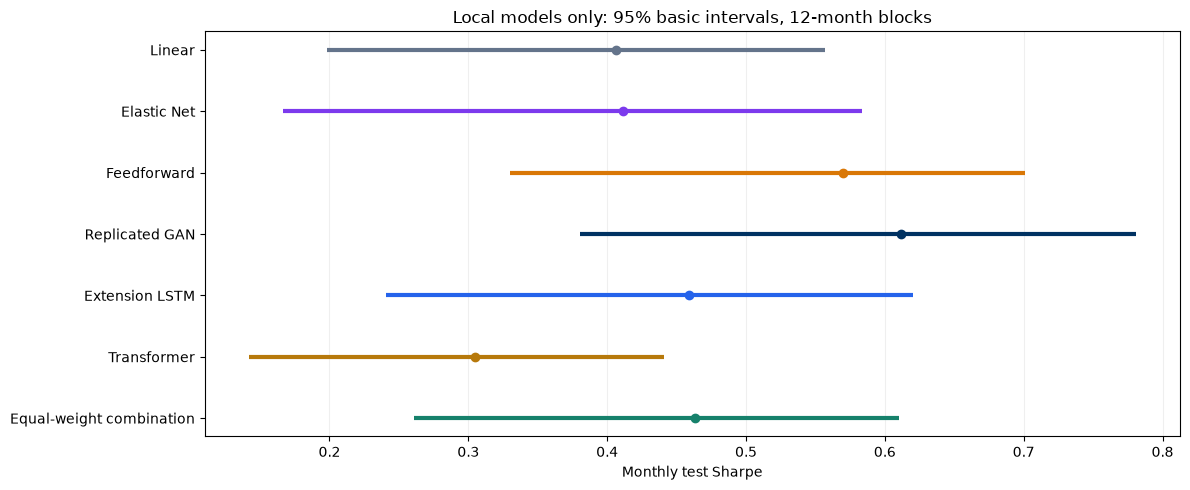

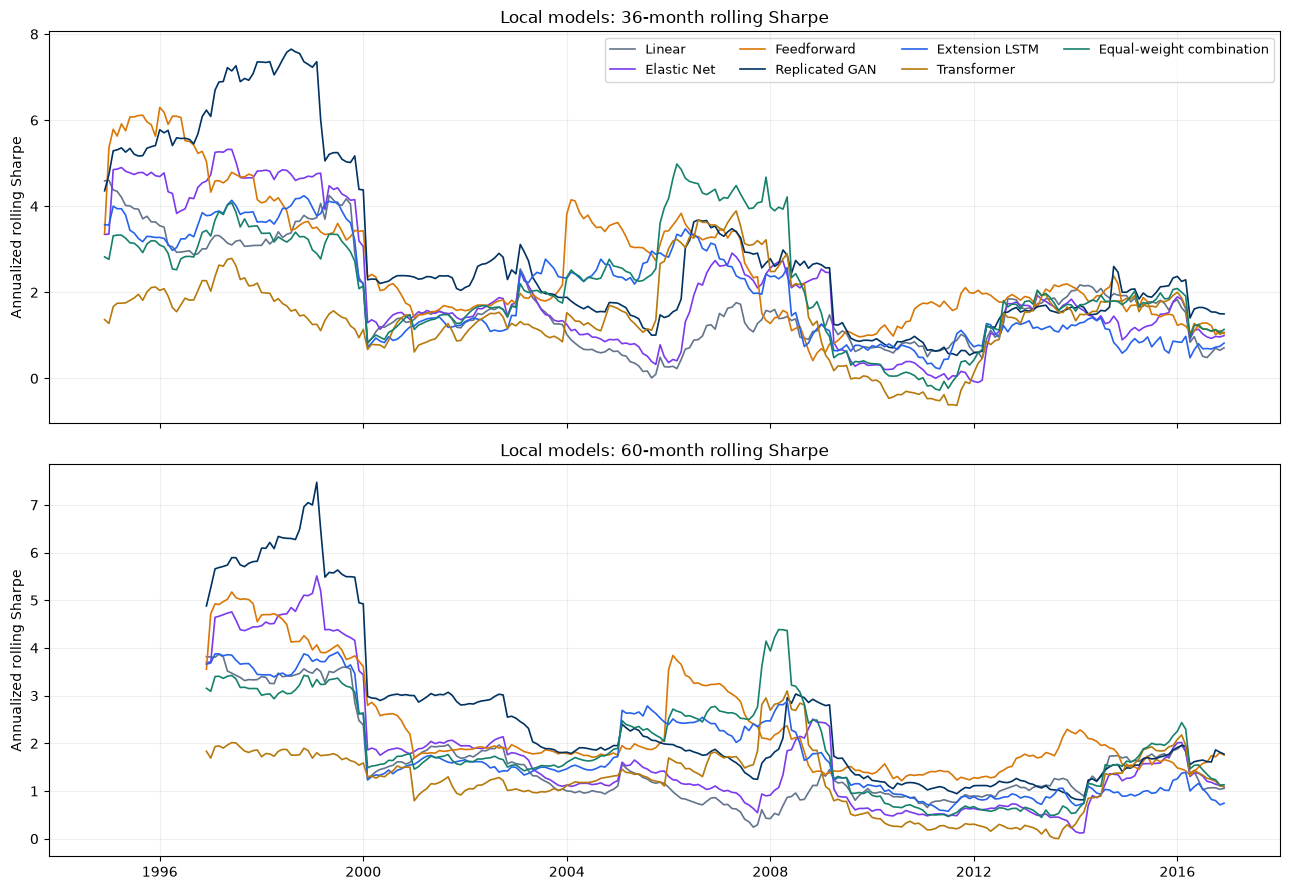

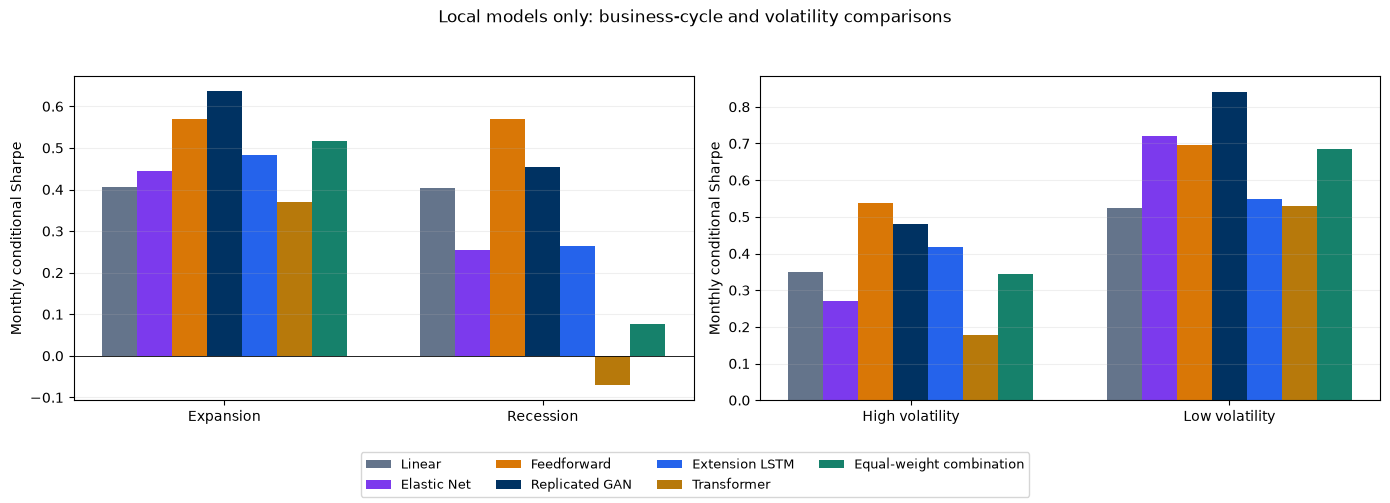

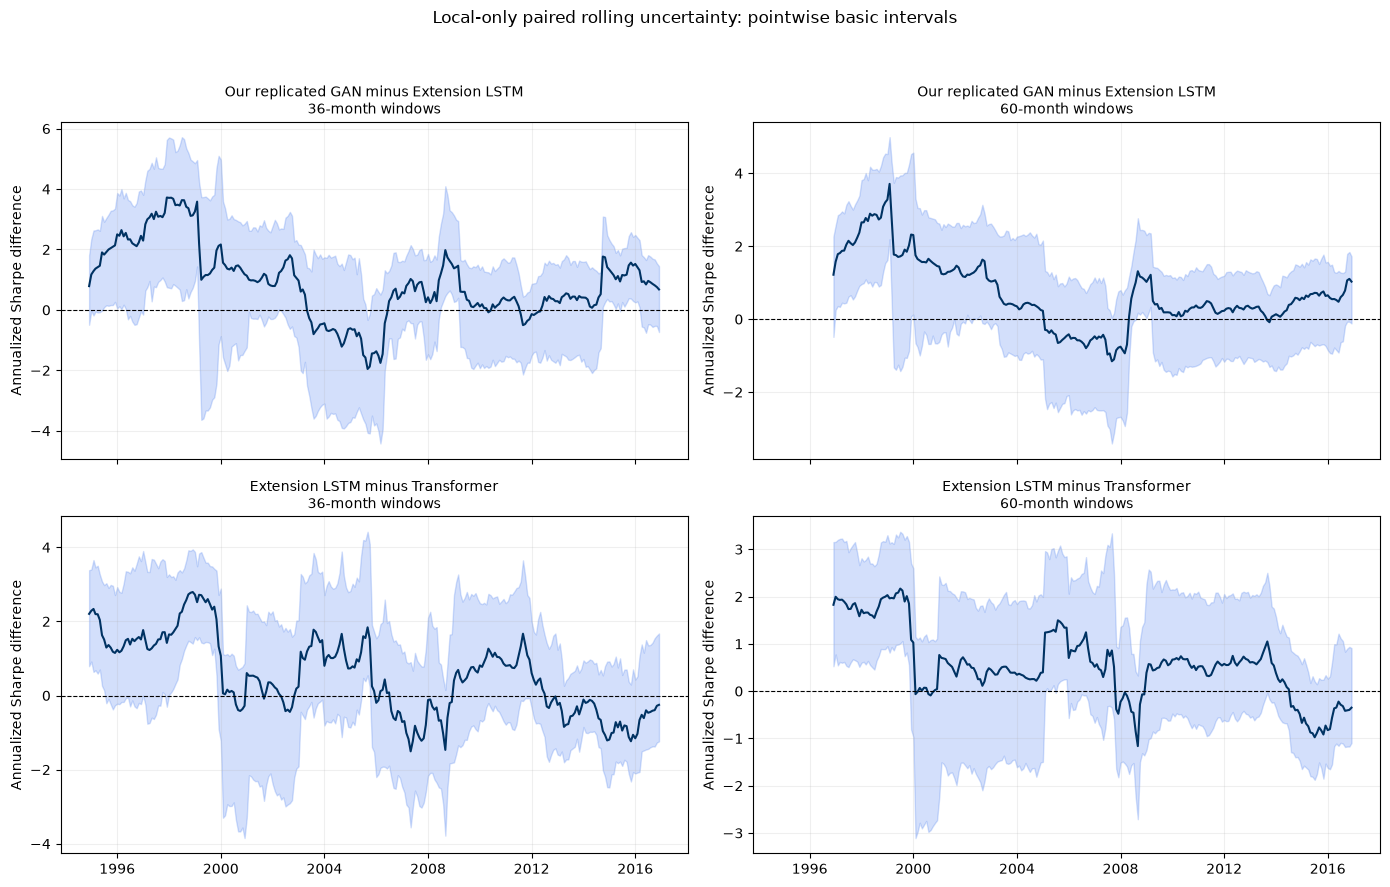

## Local-only comparison: results and interpretation

- **Scope:** Seven local portfolios, including linear, Elastic Net, feedforward, our replicated GAN, extension LSTM, Transformer, and their equal-weight combination. No original-paper factor enters this section.
- **Overall monthly test Sharpe ranking:** Our replicated GAN 0.612, Feedforward replication 0.570, Equal-weight LSTM–Transformer combination 0.463, Extension LSTM 0.459, Elastic Net replication 0.412, Linear replication 0.406, Transformer 0.304.
- **Matched architecture question:** Only extension LSTM and Transformer share the new reduced training setup. Historical replication models provide contextual comparisons.
- **Uncertainty:** The simultaneous full-test intervals are recalibrated for all 21 local pairs, rather than filtering the earlier ten-pair family. Basic intervals and six-/twelve-/twenty-four-month sensitivity are saved.
- **Rolling:** All 265 three-year and 241 five-year windows have paired uncertainty estimates using six-month blocks and 2,000 draws. Pointwise bands are not simultaneous across time.
- **Regimes:** Conditional monthly Sharpes use the established business-cycle and lagged-volatility labels. These are point estimates: this section does not provide regime-specific confidence intervals. Recession has only 26 months.
- **Meaning:** Rolling and regimes describe when and where each fixed model performs differently; uncertainty describes precision. They are analyses, not additional trained models.
- **Limits:** No retraining, transaction-cost adjustment, independent new holdout, or correction for prior research choices.

519

In [1]:
# Local-only analysis uses saved returns; no model training and no original-paper series.
from pathlib import Path
from itertools import combinations
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
LOCAL_ROOT=Path.cwd()
if not (LOCAL_ROOT/'results').exists(): LOCAL_ROOT=LOCAL_ROOT.parent
LOCAL_OUT=LOCAL_ROOT/'results/bootstrap_uncertainty/local_only'
for directory in ['tables','figures']: (LOCAL_OUT/directory).mkdir(parents=True,exist_ok=True)
local=pd.read_csv(LOCAL_ROOT/'results/rolling_oos_reduced_schedule/factors/all_model_test_factor_returns.csv',parse_dates=['date']).set_index('date')
assert local.index.equals(pd.date_range('1992-01-01','2016-12-01',freq='MS'))
local.columns=['Linear replication','Elastic Net replication','Feedforward replication','Our replicated GAN','Extension LSTM','Transformer']
local['Equal-weight LSTM–Transformer combination']=.5*(local['Extension LSTM']+local['Transformer'])
LX=local.to_numpy();LN=list(local.columns);LP=list(combinations(range(7),2));SQ=np.sqrt(12)
assert LX.shape==(300,7) and np.isfinite(LX).all()
def local_sr(x,axis=0):
    sd=x.std(axis=axis,ddof=0)
    assert (sd>1e-12).all()
    return x.mean(axis=axis)/sd
def local_boot(x,length,count,seed):
    rng=np.random.default_rng(seed);n=len(x);out=np.empty((count,x.shape[1]))
    for a in range(0,count,128):
        b=min(a+128,count)
        starts=rng.integers(n,size=(b-a,int(np.ceil(n/length))))
        ix=((starts[:,:,None]+np.arange(length))%n).reshape(b-a,-1)[:,:n]
        out[a:b]=local_sr(x[ix],axis=1)
    return out
observed=local_sr(LX)
wealth=(1+local).cumprod();dd=wealth/wealth.cummax().clip(lower=1)-1
risk=pd.DataFrame({'model':LN,'monthly_sharpe':observed,'annualized_sharpe':observed*SQ,
    'mean_monthly_return':LX.mean(0),'annualized_volatility':LX.std(0)*SQ,
    'maximum_drawdown':dd.min().values})
risk['test_rank']=risk.monthly_sharpe.rank(ascending=False,method='min').astype(int)
risk.to_csv(LOCAL_OUT/'tables/overall_performance.csv',index=False)
display(Markdown('### Local-only overall test performance — all seven portfolios'))
display(risk.sort_values('test_rank'))
local_model_rows=[];local_pair_rows=[]
for length in [6,12,24]:
    bs=local_boot(LX,length,10000,np.random.SeedSequence([20261006,777,length]))
    lo,hi=np.quantile(bs,[.025,.975],axis=0)
    for j,name in enumerate(LN):local_model_rows.append(dict(block_months=length,model=name,monthly_sharpe=observed[j],basic_lower=2*observed[j]-hi[j],basic_upper=2*observed[j]-lo[j]))
    delta=np.array([observed[i]-observed[j] for i,j in LP])
    bd=np.column_stack([bs[:,i]-bs[:,j] for i,j in LP])
    qlo,qhi=np.quantile(bd,[.025,.975],axis=0)
    critical=np.quantile(np.max(np.abs(bd-delta),axis=1),.95)
    for k,(i,j) in enumerate(LP):
        low,high=2*delta[k]-qhi[k],2*delta[k]-qlo[k]
        sl,sh=delta[k]-critical,delta[k]+critical
        local_pair_rows.append(dict(block_months=length,model_a=LN[i],model_b=LN[j],monthly_difference=delta[k],
            basic_lower=low,basic_upper=high,simultaneous_lower=sl,simultaneous_upper=sh,
            basic_direction='A higher' if low>0 else 'B higher' if high<0 else 'Unresolved',
            simultaneous_direction='A higher' if sl>0 else 'B higher' if sh<0 else 'Unresolved'))
lm=pd.DataFrame(local_model_rows);lp=pd.DataFrame(local_pair_rows)
lm.to_csv(LOCAL_OUT/'tables/model_intervals.csv',index=False);lp.to_csv(LOCAL_OUT/'tables/paired_intervals.csv',index=False)
display(Markdown('### Local-only uncertainty: primary 12-month blocks, 21 paired differences'))
display(lp[lp.block_months==12])
# Local rolling uncertainty: shared resampling within every complete window.
rolling_rows=[];rolling_summary=[]
for window in [36,60]:
    raw=local.rolling(window,min_periods=window).mean()/local.rolling(window,min_periods=window).std(ddof=0)*SQ
    for name in LN:rolling_summary.append(dict(window_months=window,model=name,windows=301-window,
        mean_annualized_rolling_sharpe=raw[name].mean(),median_annualized_rolling_sharpe=raw[name].median()))
    for endpoint in range(window-1,300):
        sample=LX[endpoint-window+1:endpoint+1];point=local_sr(sample)
        bs=local_boot(sample,6,2000,np.random.SeedSequence([20261006,777,window,endpoint]))
        delta=np.array([point[i]-point[j] for i,j in LP]);bd=np.column_stack([bs[:,i]-bs[:,j] for i,j in LP])
        lo,hi=np.quantile(bd,[.025,.975],axis=0)
        critical=np.quantile(np.max(np.abs(bd-delta),axis=1),.95)
        for k,(i,j) in enumerate(LP):
            rolling_rows.append(dict(date=local.index[endpoint],window_months=window,model_a=LN[i],model_b=LN[j],
                annualized_difference=delta[k]*SQ,basic_lower=(2*delta[k]-hi[k])*SQ,basic_upper=(2*delta[k]-lo[k])*SQ,
                simultaneous_lower=(delta[k]-critical)*SQ,simultaneous_upper=(delta[k]+critical)*SQ))
    print('Local-only rolling comparisons complete:',window)
lr=pd.DataFrame(rolling_rows);ls=pd.DataFrame(rolling_summary)
lr.to_csv(LOCAL_OUT/'tables/rolling_paired_intervals.csv',index=False);ls.to_csv(LOCAL_OUT/'tables/rolling_summary.csv',index=False)
display(Markdown('### Mean annualized rolling Sharpe — not the full-test Sharpe'))
display(ls.pivot(index='model',columns='window_months',values='mean_annualized_rolling_sharpe'))
labels=pd.read_csv(LOCAL_ROOT/'results/regime_analysis/tables/monthly_regime_labels.csv',parse_dates=['date']).set_index('date')
assert labels.index.equals(local.index)
regime_rows=[]
for family,column in [('Business cycle','business_cycle'),('Market volatility','volatility_regime')]:
    for state in labels[column].unique():
        mask=labels[column]==state
        values=local_sr(LX[mask])
        for j,name in enumerate(LN):regime_rows.append(dict(family=family,regime=state,model=name,months=int(mask.sum()),monthly_sharpe=values[j]))
lg=pd.DataFrame(regime_rows);lg.to_csv(LOCAL_OUT/'tables/regime_comparison.csv',index=False)
display(Markdown('### Conditional regime Sharpe — monthly units, point estimates only'))
display(lg.pivot(index='model',columns='regime',values='monthly_sharpe'))
short=['Linear','Elastic Net','Feedforward','Replicated GAN','Extension LSTM','Transformer','Equal-weight combination']
colors=['#64748B','#7C3AED','#D97706','#003262','#2563EB','#B7790B','#16816B']
fig,ax=plt.subplots(figsize=(12,5));q=lm[lm.block_months==12].reset_index(drop=True)
for j,r in q.iterrows():
    ax.hlines(j,r.basic_lower,r.basic_upper,color=colors[j],lw=3);ax.plot(r.monthly_sharpe,j,'o',color=colors[j])
ax.set_yticks(range(7),short);ax.invert_yaxis();ax.set_xlabel('Monthly test Sharpe');ax.set_title('Local models only: 95% basic intervals, 12-month blocks');ax.grid(axis='x',alpha=.2)
fig.tight_layout()
for ext in ['png','pdf']:fig.savefig(LOCAL_OUT/f'figures/local_overall_uncertainty.{ext}',dpi=170)
plt.show()
fig,axs=plt.subplots(2,1,figsize=(13,9),sharex=True)
for ax,w in zip(axs,[36,60]):
    sr=local.rolling(w).mean()/local.rolling(w).std(ddof=0)*SQ
    for name,label,c in zip(LN,short,colors):ax.plot(sr.index,sr[name],label=label,color=c,lw=1.2)
    ax.set_title(f'Local models: {w}-month rolling Sharpe');ax.set_ylabel('Annualized rolling Sharpe');ax.grid(alpha=.2)
axs[0].legend(ncol=4,fontsize=9);fig.tight_layout()
for ext in ['png','pdf']:fig.savefig(LOCAL_OUT/f'figures/local_rolling_comparison.{ext}',dpi=170)
plt.show()
fig,axs=plt.subplots(1,2,figsize=(14,5))
for ax,states in zip(axs,[['Expansion','Recession'],['High volatility','Low volatility']]):
    for j,(name,label,c) in enumerate(zip(LN,short,colors)):
        vals=[lg[(lg.model==name)&(lg.regime==state)].monthly_sharpe.iloc[0] for state in states]
        ax.bar(np.arange(2)+(j-3)*.11,vals,.11,color=c,label=label)
    ax.set_xticks(range(2),states);ax.set_ylabel('Monthly conditional Sharpe');ax.axhline(0,color='black',lw=.6);ax.grid(axis='y',alpha=.2)
handles,legend_labels=axs[0].get_legend_handles_labels();fig.legend(handles,legend_labels,loc='lower center',ncol=4,fontsize=9)
fig.suptitle('Local models only: business-cycle and volatility comparisons');fig.tight_layout(rect=[0,.12,1,.94])
for ext in ['png','pdf']:fig.savefig(LOCAL_OUT/f'figures/local_regime_comparison.{ext}',dpi=170)
plt.show()
fig,axs=plt.subplots(2,2,figsize=(14,9),sharex=True)
for row,(a,b) in enumerate([('Our replicated GAN','Extension LSTM'),('Extension LSTM','Transformer')]):
    for col,w in enumerate([36,60]):
        q=lr[(lr.model_a==a)&(lr.model_b==b)&(lr.window_months==w)].sort_values('date');ax=axs[row,col]
        ax.plot(q.date,q.annualized_difference,color='#003262');ax.fill_between(q.date,q.basic_lower,q.basic_upper,alpha=.2,color='#2563EB')
        ax.axhline(0,color='black',ls='--',lw=.8);ax.set_title(f'{a} minus {b}\n{w}-month windows',fontsize=10);ax.set_ylabel('Annualized Sharpe difference');ax.grid(alpha=.2)
fig.suptitle('Local-only paired rolling uncertainty: pointwise basic intervals');fig.tight_layout(rect=[0,0,1,.95])
for ext in ['png','pdf']:fig.savefig(LOCAL_OUT/f'figures/local_rolling_uncertainty.{ext}',dpi=170)
plt.show()
answer=['## Local-only comparison: results and interpretation','',
    '- **Scope:** Seven local portfolios, including linear, Elastic Net, feedforward, our replicated GAN, extension LSTM, Transformer, and their equal-weight combination. No original-paper factor enters this section.',
    '- **Overall monthly test Sharpe ranking:** '+', '.join(f'{r.model} {r.monthly_sharpe:.3f}' for r in risk.sort_values('test_rank').itertuples())+'.',
    '- **Matched architecture question:** Only extension LSTM and Transformer share the new reduced training setup. Historical replication models provide contextual comparisons.',
    '- **Uncertainty:** The simultaneous full-test intervals are recalibrated for all 21 local pairs, rather than filtering the earlier ten-pair family. Basic intervals and six-/twelve-/twenty-four-month sensitivity are saved.',
    '- **Rolling:** All 265 three-year and 241 five-year windows have paired uncertainty estimates using six-month blocks and 2,000 draws. Pointwise bands are not simultaneous across time.',
    '- **Regimes:** Conditional monthly Sharpes use the established business-cycle and lagged-volatility labels. These are point estimates: this section does not provide regime-specific confidence intervals. Recession has only 26 months.',
    '- **Meaning:** Rolling and regimes describe when and where each fixed model performs differently; uncertainty describes precision. They are analyses, not additional trained models.',
    '- **Limits:** No retraining, transaction-cost adjustment, independent new holdout, or correction for prior research choices.']
text='\n'.join(answer);(LOCAL_OUT/'results_and_answers.md').write_text(text);display(Markdown(text))
(LOCAL_OUT/'manifest.json').write_text(json.dumps({'models':LN,'original_paper_included':False,'full_test_replicates':10000,
    'full_test_blocks':[6,12,24],'rolling_replicates':2000,'rolling_block':6,'local_pair_family':21,
    'regime_uncertainty_computed':False,'training_performed':False,'seed':20261006},indent=2))


## Additional comparison figures

The original-paper figures above remain available. These four additional figures compare our replicated and extension portfolios. Regime bars are point estimates, without regime-specific confidence intervals.

| Name | PNG | PDF |
|---|---|---|
| Overall Sharpe and uncertainty among our seven portfolios | [PNG](../results/bootstrap_uncertainty/local_only/figures/local_overall_uncertainty.png) | [PDF](../results/bootstrap_uncertainty/local_only/figures/local_overall_uncertainty.pdf) |
| Three-year and five-year rolling Sharpe among our portfolios | [PNG](../results/bootstrap_uncertainty/local_only/figures/local_rolling_comparison.png) | [PDF](../results/bootstrap_uncertainty/local_only/figures/local_rolling_comparison.pdf) |
| Business-cycle and volatility regime comparisons | [PNG](../results/bootstrap_uncertainty/local_only/figures/local_regime_comparison.png) | [PDF](../results/bootstrap_uncertainty/local_only/figures/local_regime_comparison.pdf) |
| Rolling paired differences with uncertainty | [PNG](../results/bootstrap_uncertainty/local_only/figures/local_rolling_uncertainty.png) | [PDF](../results/bootstrap_uncertainty/local_only/figures/local_rolling_uncertainty.pdf) |


## Final results — bullet-point summary

- **No retraining:** All analyses reuse the same 300 test months, January 1992–December 2016.
- **Method:** 10,000 paired circular-block samples for each of 6-, 12-, and 24-month blocks. Twelve months is the primary illustrative setting.
- **Observed monthly Sharpe and primary 95% basic intervals:**
  - **Original-paper GAN:** 0.750, interval [0.442, 0.973].
  - **Our replicated GAN:** 0.612, interval [0.380, 0.783].
  - **Extension LSTM:** 0.459, interval [0.244, 0.626].
  - **Transformer:** 0.304, interval [0.146, 0.439].
  - **Equal-weight LSTM–Transformer combination:** 0.463, interval [0.265, 0.612].
- **LSTM versus Transformer:** Observed monthly Sharpe difference is **0.155**, with a primary basic interval of **[−0.049, 0.365]**. Zero remains inside the basic and simultaneous intervals at all three block lengths.
- **Blend versus LSTM:** The observed blend advantage is approximately **0.004** monthly Sharpe. The primary LSTM-minus-blend basic interval is **[−0.132, 0.119]**, leaving the direction unresolved.
- **Authors versus replication:** The primary authors-minus-Code 07 basic interval is **[−0.037, 0.256]**. This does not establish numerical equivalence or exact replication.
- **More comparisons:** All ten portfolio pairs are compared across basic, percentile, and simultaneous intervals. Separate tables examine block-length robustness, IID resampling, interval widths, and annualization.
- **Interpretation:** Report method-sensitive results explicitly. Independent-month resampling is a diagnostic, and multiplying by √12 changes units without changing zero-exclusion conclusions.
- **Limits:** These approximate intervals quantify sampling uncertainty for fixed portfolios. They do not resolve different training procedures, prior test inspection, transaction costs, or structural changes.
- **Connection to earlier codes:** Code 012 adds uncertainty to the point comparisons in Codes 07–11; it does not replace their rolling or regime analyses.

### Rolling results

## Rolling uncertainty — results and interpretation

- All 265 complete 36-month windows and 241 complete 60-month windows are analyzed without retraining.
- Figures show pointwise basic intervals. Simultaneous table intervals adjust for ten pairs within each window, not across dates.
- **36 months, LSTM minus Transformer:** LSTM has higher observed Sharpe in 168/265 windows. Basic intervals favor LSTM in 39, favor Transformer in 0, and leave 226 unresolved. These overlapping counts are descriptive, not independent evidence.
- **60 months, LSTM minus Transformer:** LSTM has higher observed Sharpe in 193/241 windows. Basic intervals favor LSTM in 45, favor Transformer in 0, and leave 196 unresolved. These overlapping counts are descriptive, not independent evidence.
- Larger or smaller point estimates should be interpreted with their window-specific intervals. Short windows have limited information; apparent performance changes need not be precisely estimated.
- Three-, six-, and twelve-month block comparisons at December endpoints assess local sensitivity. They do not select a model or define a trading signal.
- Labels now distinguish the original-paper GAN, our replicated GAN, the extension architectures, and the equal-weight LSTM–Transformer combination.

### Additional results among our models

- **Scope:** Seven local portfolios, including linear, Elastic Net, feedforward, our replicated GAN, extension LSTM, Transformer, and their equal-weight combination. No original-paper factor enters this section.
- **Overall monthly test Sharpe ranking:** Our replicated GAN 0.612, Feedforward replication 0.570, Equal-weight LSTM–Transformer combination 0.463, Extension LSTM 0.459, Elastic Net replication 0.412, Linear replication 0.406, Transformer 0.304.
- **Matched architecture question:** Only extension LSTM and Transformer share the new reduced training setup. Historical replication models provide contextual comparisons.
- **Uncertainty:** The simultaneous full-test intervals are recalibrated for all 21 local pairs, rather than filtering the earlier ten-pair family. Basic intervals and six-/twelve-/twenty-four-month sensitivity are saved.
- **Rolling:** All 265 three-year and 241 five-year windows have paired uncertainty estimates using six-month blocks and 2,000 draws. Pointwise bands are not simultaneous across time.
- **Regimes:** Conditional monthly Sharpes use the established business-cycle and lagged-volatility labels. These are point estimates: this section does not provide regime-specific confidence intervals. Recession has only 26 months.
- **Meaning:** Rolling and regimes describe when and where each fixed model performs differently; uncertainty describes precision. They are analyses, not additional trained models.
- **Limits:** No retraining, transaction-cost adjustment, independent new holdout, or correction for prior research choices.

- **Original-paper benchmark retained:** Parts 1–10 continue to compare our results with the original-paper portfolio. Part 11 adds a complementary within-project comparison.
